# Сверточные сети

Разнообразие слоев для сверточной сети опирается на понятие тензор и его обработку в средах типа TensorFlow.

Тензор - объект линейной алгебры, линейно преобразующий элементы одного линейного пространства в элементы другого

Ранг тензора — это количество его индексов

Сверточные нейронные сети - это нейронные сети приспособленные впервую очередь для задач распознования образов. В их основе лежат работы в области изучения зрительной коры головного мозга. Их отличительная черта - добавление сверточных и пуллинговых слоев в архитектуру нейронной сети


## 1.1 Сверточный слой

Посмотрим как работает наложение фильтра на изображение

Прочитаем изображение и следаем его свертку с некоторым фильтром (воспользуемся средствами OpenCV (cv2) и scipy)




In [7]:
!pip install pooch


[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [1]:
!pip list | grep pooc

pooch                     1.8.2


In [1]:
import cv2
import numpy as np
from scipy import datasets

i_mage = datasets.ascent()

Исходное изображение

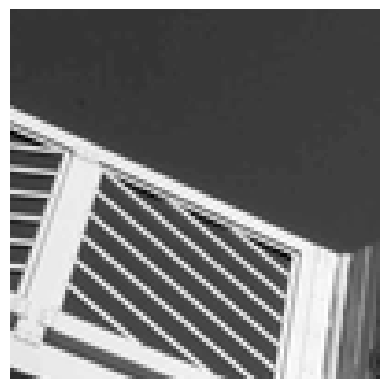

In [2]:
import matplotlib.pyplot as plt

plt.grid(False)
plt.gray()
plt.axis("off")
plt.imshow(i_mage[50:150, :100])
plt.show()

Создадим фильтр

In [3]:
i_mage = i_mage.astype(np.float32)
i_transformed = np.copy(i_mage)
size_x = i_transformed.shape[0]
size_y = i_transformed.shape[1]

# Фильтры края.

# Разные фильтры.
filter = [[0, 1, 0], [1, -4, 1], [0, 1, 0]]

# Много разных
# filter = [ [-1, -2, -1], [0, 0, 0], [1, 2, 1]]
# filter = [ [-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]

# зададим вес для свертки
weight = 1

Наложим фильтр на изображение, используем скользящее окно и поэлементное вычисление свертки

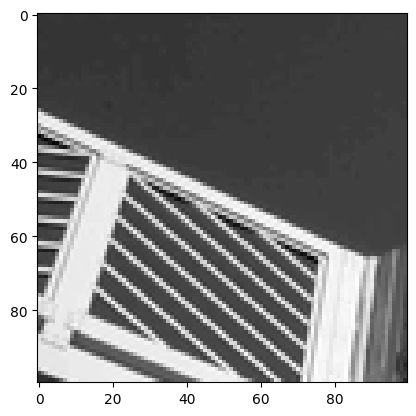

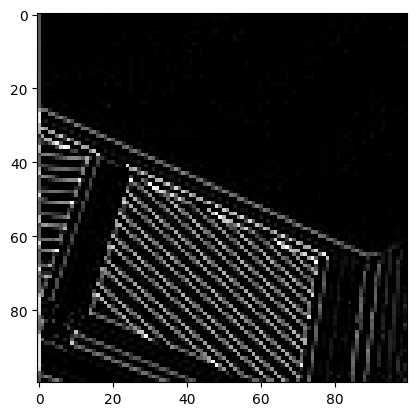

In [4]:
for x in range(1, size_x - 1):
    for y in range(1, size_y - 1):
        # convolution
        convolution = 0.0
        convolution = convolution + (i_mage[x - 1, y - 1] * filter[0][0])
        convolution = convolution + (i_mage[x, y - 1] * filter[0][1])
        convolution = convolution + (i_mage[x + 1, y - 1] * filter[0][2])
        convolution = convolution + (i_mage[x - 1, y] * filter[1][0])
        convolution = convolution + (i_mage[x, y] * filter[1][1])
        convolution = convolution + (i_mage[x + 1, y] * filter[1][2])
        convolution = convolution + (i_mage[x - 1, y + 1] * filter[2][0])
        convolution = convolution + (i_mage[x, y + 1] * filter[2][1])
        convolution = convolution + (i_mage[x + 1, y + 1] * filter[2][2])
        convolution = convolution * weight
        if convolution < 0:
            convolution = 0
        if convolution > 255:
            convolution = 255
        i_transformed[x, y] = convolution

# Plot исходное изображение
plt.gray()
plt.grid(False)
plt.imshow(i_mage[50:150, :100])
# plt.axis('off')
plt.show()
# Plot фильтрованное изображение
plt.gray()
plt.grid(False)
plt.imshow(np.abs(i_transformed[50:150, :100]))
# plt.axis('off')
plt.show()

Построим модель слоя при прямом распространении сигнала через сверточный слой

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
# прямое распространение
def ConvLayer_Forward(Tensor=None, W=None, b=None):
    # на вход:
    # Tensor  - входное изображение
    # W - значения весов нейронов (ядра-фильтры)
    # b - значение сдвигов нейронов
    # на выходе: Output - результат свертки (число каналов = числу фильтров(ядер))

    Output = []
    # print(Tensor.shape)

    iw = 0
    # проходимся по каждому из фильтров
    for f in W:
        print(f)
        output = np.zeros(Tensor.shape[:-1])
        # print(output.shape, f.shape)
        # проходимся по фильтрам
        for y in range(Tensor.shape[0] - f.shape[0]):
            for x in range(Tensor.shape[1] - f.shape[1]):
                sum = 0
                sum = b[iw]  # сразу прибавляем смещение
                sum = sum + np.sum(
                    np.dot(f, Tensor[y : y + f.shape[0], x : x + f.shape[1]])
                )

                output[y, x] = (
                    sum.copy()
                )  # записываем результат свёртки в выходной тензор
        # print(x,y)
        Output.append(output.copy())
        iw += 1
    Output = np.array(Output)
    return Output

Построим модель слоя при обратном распространении сигнала через слой

In [7]:
def Convolution_Backprop(delta_conv_prev=None, conv_input=None, K=None):
    # входы:
    # delta_conv_prev - ошибка со следующего слоя
    # conv_input - входное изображение на слое
    # K - текущее значение фильтров(ядер - нейроных весов) слоя
    # на выходе
    # dK - поправки для фильтров (без скорости обучения)
    # db - поправки для сдвигов нейрона без скорости обучения
    # I_back - ошибку на входе в сверточный слой
    # Backpropagation

    (n_f, n_c, _) = K.shape
    (_, orig_dim, _) = conv_input.shape
    # строим размер
    dout = np.zeros(conv_input.shape)
    dK = np.zeros(K.shape)
    dbias = np.zeros((n_f, 1))
    iw = 0
    for f in K:
        # по каналам
        out_y = 0
        for y in range(conv_input.shape[0] - f.shape[0]):
            out_x = 0
            for x in range(conv_input.shape[1] - f.shape[1]):
                # градиент loss по всем текущим точкам
                dK[iw, :, :] += (
                    delta_conv_prev[iw, y, x]
                    * conv_input[y : y + f.shape[0], x : x + f.shape[1], 0]
                )
                # print(np.sum(np.abs(delta_conv_prev[iw, y, x] * conv_input[ y:y+f.shape[0], x:x+f.shape[1],:])))
                # перенос loss через этот слой
                dout[y, x, :] += np.sum(delta_conv_prev[iw, y, x] * f)

        # loss gradient of the bias
        dbias[iw] = np.sum(delta_conv_prev[iw])
        iw += 1

    return dout, dK, dbias


Создадим 10 фильтров(ядер-нейронов) сверточного слоя как случайные равномерные с размером 3х3 , создадим изображение (белый прямоугольник на черном фоне) и примени к этому изображению сверточный слой

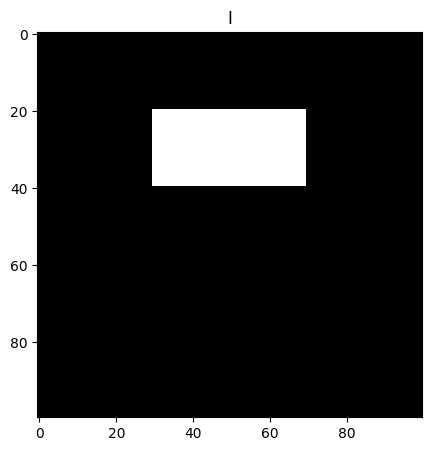

In [8]:
K = np.random.random((10, 3, 3)) * 10 - 5
b = np.random.random(10) * 0.1

K[0, :, 0] = -1
K[0, :, 2] = 1
K[0, :, 1] = 0
K[0, 1, :] = K[0, 1, :] * 2

I = np.zeros((100, 100, 1))

I[20:40, 30:70, 0] = 1

plt.figure(figsize=(8, 5))
plt.title("I")
plt.imshow(I);

Делаем прямой проход и вычисляем 10 изображений результатов

[[-1.  0.  1.]
 [-2.  0.  2.]
 [-1.  0.  1.]]
[[ 1.90381803 -4.84461663 -0.8664585 ]
 [ 2.46602116  3.86580543  0.19214336]
 [-4.35820695 -1.09865809  4.61100117]]
[[-4.5916314  -0.44108808  3.12105506]
 [-3.0974138  -3.39995152 -3.90679486]
 [-3.81452252 -1.04779638  0.13294147]]
[[-3.00230851  3.73152832 -0.83996057]
 [ 1.58393817 -2.18844455 -3.0121055 ]
 [ 3.31483147  2.77417723  2.32171928]]
[[-2.9676442   1.73972746 -0.55409436]
 [ 4.36361013 -3.85449795 -0.56737381]
 [-2.58925044  0.98572554  2.97848267]]
[[ 3.46281954 -4.12249448  4.47835413]
 [ 1.01051644  2.49589725 -0.97478922]
 [ 4.35183752  1.9898429   1.71202329]]
[[-4.14018246  0.99456949 -4.86721583]
 [-0.14918689 -2.06895548 -4.0373183 ]
 [-2.93080984 -3.74129483  0.11885454]]
[[-2.63402732  1.10044987  0.8544258 ]
 [-1.21872467  4.43823358 -2.95936206]
 [ 3.27838286  0.34332934 -1.12513143]]
[[-1.57951027 -1.32734958  0.77384731]
 [ 3.14081191 -2.09319229  0.71893616]
 [-3.8613339  -2.41887115 -2.90329536]]
[[-2.97679

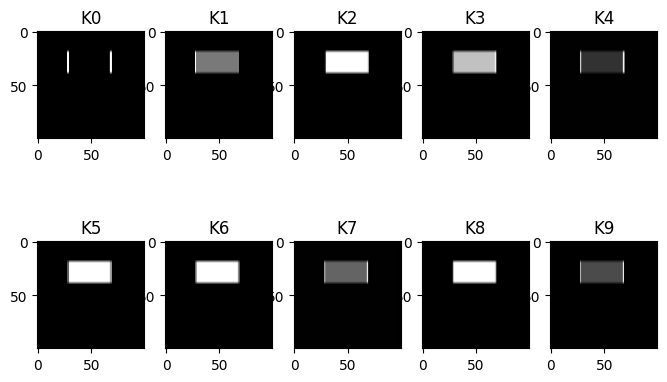

In [9]:
I_ = ConvLayer_Forward(Tensor=I, W=K, b=b)

plt.figure(figsize=(8, 5)) # Changed figsize to make the plot smaller
for i in [0, 1, 2, 3, 4]:
    for j in [0, 1]:
        plt.subplot(2, 5, i + j * 5 + 1)
        plt.title("K" + str(i + j * 5))
        plt.imshow(np.abs((I_[i + j * 5, :, :]) / np.max(np.abs(I_[i + j * 5, :, :]))))

plt.show()

Делаем обратный проход:
 создаем истиный результат (It) и находим дельту Loss_e (ошибку слоя на выходе (она должна прийти из следующего за текущим слоя ))

 Вернем:

 - dK - поправки для фильтров (без скорости обучения)
 - db - поправки для сдвигов нейрона без скорости обучения
 - I_back - ошибку на входе в сверточный слой

In [10]:
It = I_ + np.random.random((10, 100, 100)) * 1 - 0.5

Loss_e = It - I_

I_back, dK, db = Convolution_Backprop(delta_conv_prev=Loss_e, conv_input=I, K=K)

In [11]:
dK

array([[[ 8.6930947 , 10.15535632,  9.97078269],
        [ 8.92846869, 10.01043895, 10.06890111],
        [ 8.90162999,  9.93304568, 10.7251535 ]],

       [[-2.05448335, -1.35499468, -2.11216921],
        [-2.96636829, -2.07968318, -3.1690285 ],
        [-1.64054646, -0.24732805, -0.55199742]],

       [[ 3.03062764,  3.75024332,  2.01966679],
        [ 4.68764312,  4.29966791,  2.65023043],
        [ 0.35992382,  0.34652269, -2.28080059]],

       [[-2.01751189, -2.7321556 , -1.99120468],
        [-5.29335431, -6.51448416, -4.25344086],
        [-5.58888194, -7.01839205, -5.03964471]],

       [[-4.29032398, -2.64764767, -0.31229807],
        [-5.67856415, -4.28339727, -2.43855216],
        [-3.31175327, -1.92358698,  0.32854293]],

       [[12.56366763, 10.57633001,  7.0859063 ],
        [ 8.51433517,  6.7211268 ,  3.59863722],
        [ 3.87690088,  2.07038832, -1.56239463]],

       [[ 5.02908727,  6.11956565,  8.18378291],
        [ 4.54368164,  4.92083534,  7.16264356],
        

In [12]:
db

array([[ 17.38381843],
       [ 27.94713754],
       [-32.99384828],
       [-48.02946822],
       [-45.5740201 ],
       [  9.70718757],
       [ -5.97665727],
       [ 11.81485306],
       [ 30.93308112],
       [ 24.31650474]])

In [13]:
I_back[:40, :40, 0]

array([[ 25.35172456,  -1.1155894 ,  -9.37981302, ...,  -1.52129799,
         -4.4209851 ,  -6.88455581],
       [  5.1547117 ,  -2.00541471,  -3.92859561, ...,   7.64114279,
         -2.37556069,  -8.90556801],
       [  8.04730589,   3.03443063,   0.83366315, ...,  -9.14349484,
         10.57954927,   6.37848975],
       ...,
       [  6.2017652 ,   5.73320237,   7.05576898, ...,  -2.13343884,
         -5.64887186,  -1.15254518],
       [ -0.31132823,   5.93306317, -10.55842994, ...,   6.49452918,
         -7.29949935, -15.20586857],
       [ -1.81428723,  -1.42554454, -13.4894211 , ...,  -3.15978849,
          7.72991947,   6.84126459]])

результат обратного прохода по свертке

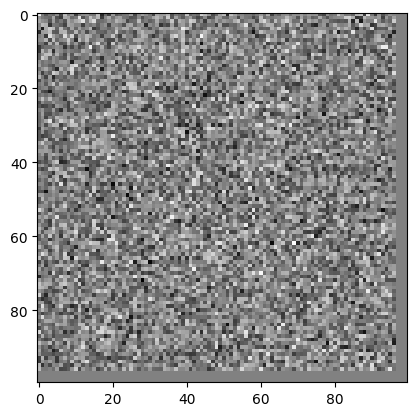

In [14]:
plt.imshow(I_back[:, :, 0] / np.max(I_back + 1))
plt.show()


## 1.2. Слой Пулинга

Посмотрим на пулинг с точки зрения обработки изображений

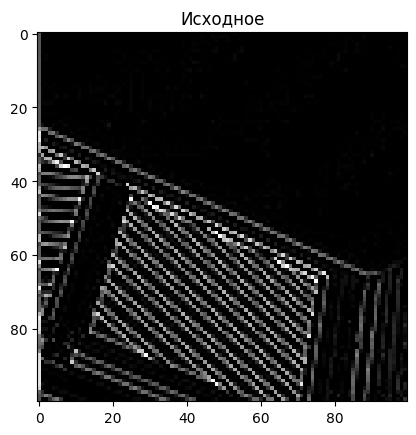

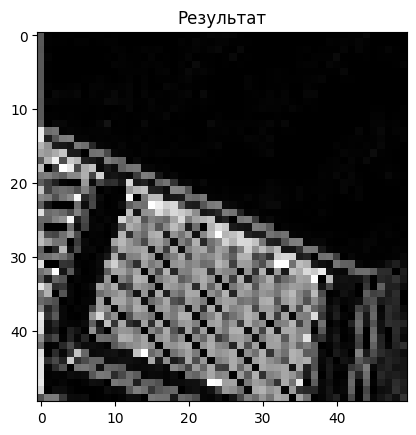

In [15]:
new_x = int(size_x / 2)
new_y = int(size_y / 2)
# создаем изображение для накопрения результатов пулинга
newImage = np.zeros((new_x, new_y))
for x in range(0, size_x, 2):
    for y in range(0, size_y, 2):
        # вычисляем один пиксель
        pixels = []
        pixels.append(i_transformed[x, y])
        pixels.append(i_transformed[x + 1, y])
        pixels.append(i_transformed[x, y + 1])
        pixels.append(i_transformed[x + 1, y + 1])
        newImage[int(x / 2), int(y / 2)] = max(pixels)

# исходное
plt.gray()
plt.grid(False)
plt.imshow(i_transformed[50:150, :100])
plt.title("Исходное")
# plt.axis('off')
plt.show()

# Plot результирующее изображение
plt.gray()
plt.grid(False)
plt.imshow(newImage[25:75, :50])
plt.title("Результат")
# plt.axis('off')
plt.show()

Содздадим модель слоя пулинга при прямом проходе

In [16]:
def Maxpool_Forward(image, k=2, s=2):
    # kernel size - k
    # stride  - s
    # image - входное изображение
    h_prev, w_prev, n_c = image.shape

    # Определим размер выхода слоя
    h = int((h_prev - k) / s) + 1
    w = int((w_prev - k) / s) + 1

    # создадим выходной тензор.

    MaxPool_ = np.zeros((h, w, n_c))

    # скользим по каналам тензора
    for i in range(n_c):
        y = out_y = 0
        # вертикально
        while y + k <= h_prev:
            x = out_x = 0
            # горизонтально
            while x + k <= w_prev:
                # выбрали максимальное значение
                MaxPool_[out_y, out_x, i] = np.max(image[y : y + k, x : x + k, i])
                x += s
                out_x += 1
            y += s
            out_y += 1
    return MaxPool_

Обратьный проход по пулингу

In [17]:
def Maxpool_Backprop(I_pool_inp=None, delta_pool_prev=None, k=2, s=2):
    # kernel size - k
    # stride  - s

    h_prev, w_prev, n_c = I_pool_inp.shape
    h_, w_, n_d = delta_pool_prev.shape
    # Определим размер выхода слоя
    h = h_prev
    w = w_prev

    # создадим выходной тензор.
    dout = np.zeros((h_prev, w_prev, n_c))

    # скользим по каналам тензора
    for i in range(n_c):
        y = out_y = 0
        # вертикально

        while out_y + k <= h_prev:
            x = out_x = 0
            # горизонтально

            while out_x + k <= w_prev:
                # выбрали максимальное значение (берем его координаты в выдленном куске входной картинки
                imax = np.argmax(I_pool_inp[out_y : out_y + k, out_x : out_x + k, i])
                # print(imax)
                # maxPooling
                if np.isscalar(imax):
                    ind = np.unravel_index(
                        np.argmax(I_pool_inp[out_y : out_y + k, out_x : out_x + k, i]),
                        I_pool_inp[out_y : out_y + k, out_x : out_x + k, i].shape,
                    )
                    # добавляем дельту только в максимум (если средний, то добавим всем элементам без поиска максимума во входной картинке
                    dout[out_y + ind[0], out_x + ind[1], i] += delta_pool_prev[y, x]
                    # print(out_y+ind[0], out_x+ind[1],dout[out_y+ind[0], out_x+ind[1], i] )
                # AveragPooling
                # dout[out_y:out_y+k, out_x:out_x+k, i]  = delta_pool_prev[y,x]
                # SumPooling
                # dout[out_y:out_y+k, out_x:out_x+k, i]  = delta_pool_prev[y,x]/k**2
                x += 1
                out_x += s
            y += 1
            out_y += s
    return dout

Посмотрим как сработал пулинг

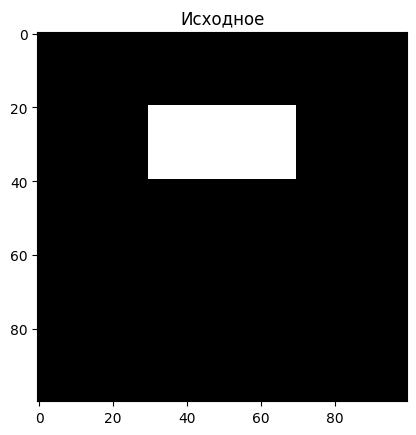

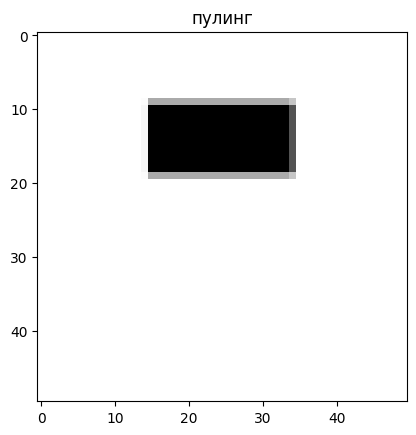

In [18]:
I = np.zeros((100, 100, 1))

I[20:40, 30:70, 0] = 1

I_max_pool = Maxpool_Forward(I_[2, :, :].reshape((100, 100, 1)), k=2, s=2)

plt.imshow(I[:, :, 0])
plt.title("Исходное")
plt.show()

plt.imshow(I_max_pool[:, :, 0] / np.max(I_max_pool + 1))
plt.title("пулинг")
plt.show()

Запустим обратное распространение по пулингу

In [19]:
It = I_max_pool.reshape((50, 50, 1)) + np.random.random((50, 50, 1)) * 1 - 0.5

Loss_e = It - I_max_pool


dI_back = Maxpool_Backprop(
    I_pool_inp=I_[0, :, :].reshape((100, 100, 1)), delta_pool_prev=Loss_e, k=2, s=2
)

/var/folders/q0/6dg0mcx94x77w7989718hdbm0000gn/T/ipykernel_88114/3421324979.py:34: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dout[out_y + ind[0], out_x + ind[1], i] += delta_pool_prev[y, x]


Посмотрим как сработало

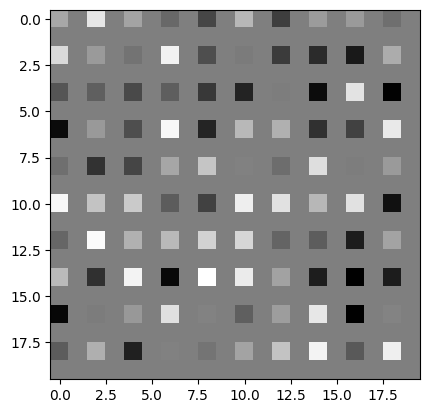

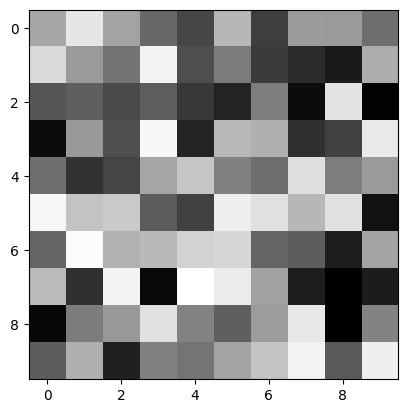

In [20]:
plt.imshow(dI_back[:20, :20, 0] / np.max(dI_back + 1))
plt.show()
plt.imshow(Loss_e[:10, :10, 0] / np.max(Loss_e + 1))
plt.show()


## 1.3. Слой обратной свертки

In [21]:
import tensorflow as tf


def test_conv2d_transpose():
    # входной пакет = (1, 2, 2, 1) -> (batch_size, height, width, channels) - 2x2x1 одна картинка в пакете
    x = tf.constant(np.array([[[[1], [2]], [[3], [4]]]]), tf.float32)

    # форма = (3, 3, 1, 1) -> (height, width, input_channels, output_channels) - 3x3x1 фильтр
    f = tf.constant(
        np.array([[[[1]], [[1]], [[1]]], [[[1]], [[1]], [[1]]], [[[1]], [[1]], [[1]]]]),
        tf.float32,
    )

    conv = tf.nn.conv2d_transpose(
        x, f, output_shape=(1, 4, 4, 1), strides=[1, 2, 2, 1], padding="SAME"
    )
    # для TF 1.14
    # with tf.Session() as session:
    #    result = session.run(conv)
    # TF 2.0
    result = conv.numpy()
    return result

Посмотрим результат обратной свертки

In [22]:
res = test_conv2d_transpose()
res.reshape((4, 4))


array([[ 1.,  1.,  3.,  2.],
       [ 1.,  1.,  3.,  2.],
       [ 4.,  4., 10.,  6.],
       [ 3.,  3.,  7.,  4.]], dtype=float32)

## 1.4 Пакетная нормализация

In [23]:
# необходимые пакеты
import matplotlib.pyplot as plt
import seaborn

import numpy as np
import pandas as pd

https://kratzert.github.io/2016/02/12/understanding-the-gradient-flow-through-the-batch-normalization-layer.html

In [24]:
def batchnorm_forward(x, gamma, beta, eps):
    N, D = x.shape

    # 1: вычислим среднее
    mu = 1.0 / N * np.sum(x, axis=0)
    # 2: центрируем тензоры по каждому признаку
    xmu = x - mu
    # 3: считаем квадрат отклонений
    sq = xmu**2
    # 4: дисперсия
    var = 1.0 / N * np.sum(sq, axis=0)
    # 5: добавим еще чуть-чуть для корректных расчетов потом и найдем корень
    sqrtvar = np.sqrt(var + eps)
    # 6: определим обратную величину к сигма
    ivar = 1.0 / sqrtvar
    # 7: вычислим новую варианцию
    xhat = xmu * ivar
    # 8: поднимаем уровень по Гамме
    gammax = gamma * xhat
    # 9: выход модели
    out = gammax + beta
    # сохраним все, что сделали
    cache = (xhat, gamma, xmu, ivar, sqrtvar, var, eps, mu)
    return out, cache

In [25]:
def batchnorm_backward(dout, cache):
    # достаем из cache все данные о том как был обработан тензор
    xhat, gamma, xmu, ivar, sqrtvar, var, eps, mu = cache

    # gвычисляем размер входа и выхода
    N, D = dout.shape

    # 9 : вычисляем производные для параметров (бетта )
    dbeta = np.sum(dout, axis=0)
    # 8 : Вычислим производную для гаммы
    dgammax = dout
    dgamma = np.sum(dgammax * xhat, axis=0)
    dxhat = dgammax * gamma

    # 7 :
    divar = np.sum(dxhat * xmu, axis=0)
    dxmu1 = dxhat * ivar

    # 6 :
    dsqrtvar = -1.0 / (sqrtvar**2) * divar

    # 5 :
    dvar = 0.5 * 1.0 / np.sqrt(var + eps) * dsqrtvar

    # 4 :
    dsq = 1.0 / N * np.ones((N, D)) * dvar

    # 3 :
    dxmu2 = 2 * xmu * dsq

    # 2 :
    dx1 = dxmu1 + dxmu2
    dmu = -1 * np.sum(dxmu1 + dxmu2, axis=0)

    # 1 :
    dx2 = 1.0 / N * np.ones((N, D)) * dmu

    # 0 :
    dx = dx1 + dx2

    return dx, dgamma, dbeta


In [26]:
N = 10
D = 3

tensor_input = np.random.random((N, D)) / 2
tensor_input[(N // 2) :, :] += 0.5
print(tensor_input[0, :], tensor_input[-1, :])

[0.41082116 0.09717287 0.28203729] [0.57602701 0.57434447 0.62518343]


In [27]:
tensor_out, cache = batchnorm_forward(tensor_input, 0.3, 0.5, 0.001)
print("до: ", tensor_input[0, :], "    после: ", tensor_out[0, :])
print("до: ", tensor_input[-1, :], "    после: ", tensor_out[-1, :])
print("mu: ", cache[7], "\nsigma: ", cache[5])

до:  [0.41082116 0.09717287 0.28203729]     после:  [0.36366156 0.15213963 0.29338382]
до:  [0.57602701 0.57434447 0.62518343]     после:  [0.5866723  0.68043898 0.62247943]
mu:  [0.51182037 0.41136801 0.49747481] 
sigma:  [0.04839032 0.0724229  0.09684904]


In [28]:
dout = np.random.random((N, D)) / 10
dx, dgamma, dbeta = batchnorm_backward(dout, cache)
print("dx: ", dx[0, :])
print("dgamma: ", dgamma)
print("dbeta: ", dbeta)

dx:  [-0.03886038 -0.00167805  0.04448574]
dgamma:  [-0.01862556  0.04865118  0.0288783 ]
dbeta:  [0.55304437 0.39806167 0.52355004]


## 1.6. Активационные функции

In [29]:
from IPython.display import Image

![img](https://raw.githubusercontent.com/Nustle/NeuralNetworks/main/hw9/sem9_1.png)

In [ ]:
# необходимые пакеты для tensorflow
# import matplotlib.pyplot as plt
# import seaborn

# import numpy as np
# import pandas as pd

# from tensorflow.keras.models import Model
# from tensorflow.keras.datasets import mnist, fashion_mnist, cifar10
# from tensorflow.keras.layers import (
#     Dense,
#     Flatten,
#     Input,
#     AveragePooling2D,
#     Conv2DTranspose,
#     Activation,
#     MaxPooling2D,
#     Conv2D,
#     BatchNormalization,
# )
# from tensorflow.keras import backend as K
# from tensorflow.keras.optimizers import Adam
# from tensorflow.keras import utils
# # from google.colab import files

# from tensorflow.keras.preprocessing import image
# import numpy as np

# from PIL import Image
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler

In [31]:
# необходимые пакеты
import matplotlib.pyplot as plt
import seaborn

import numpy as np
import pandas as pd

from torch.nn import Module

from torch.nn import (
    Linear,
    Flatten,
    Conv2d,
    AvgPool2d,
    ConvTranspose2d,
    ReLU,Sigmoid,
    MaxPool2d,
    BatchNorm2d,
)
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms

import torch
from torch import nn
from torch import optim

import numpy as np

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

**MNIST**

Строим данные для сверточной сети

In [32]:
transfor_gray = torchvision.transforms.Compose([transforms.ToTensor(),])

In [33]:
pwd

'/Users/adilismailov/Desktop/ИУ9-72Б/Нейронки/sem9'

In [34]:
# загрузка тренировочных и тестовых данных
train_dataset = torchvision.datasets.MNIST(root='./data',  
                                             train=True,
                                             transform=transfor_gray,
                                             download=True)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset,
                                           batch_size=64,
                                           shuffle=True)

batch_size_test = 8
test_dataset = torchvision.datasets.MNIST(root='./data',  
                                       train=False,
                                       download=True, 
                                       transform=transfor_gray)
test_loader = torch.utils.data.DataLoader(test_dataset, 
                                         batch_size=batch_size_test,
                                         shuffle=False)

100%|███████████████████████████████████████| 9.91M/9.91M [00:22<00:00, 435kB/s]
100%|██████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 53.8kB/s]
100%|███████████████████████████████████████| 1.65M/1.65M [00:03<00:00, 417kB/s]
100%|██████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 1.05MB/s]


данные

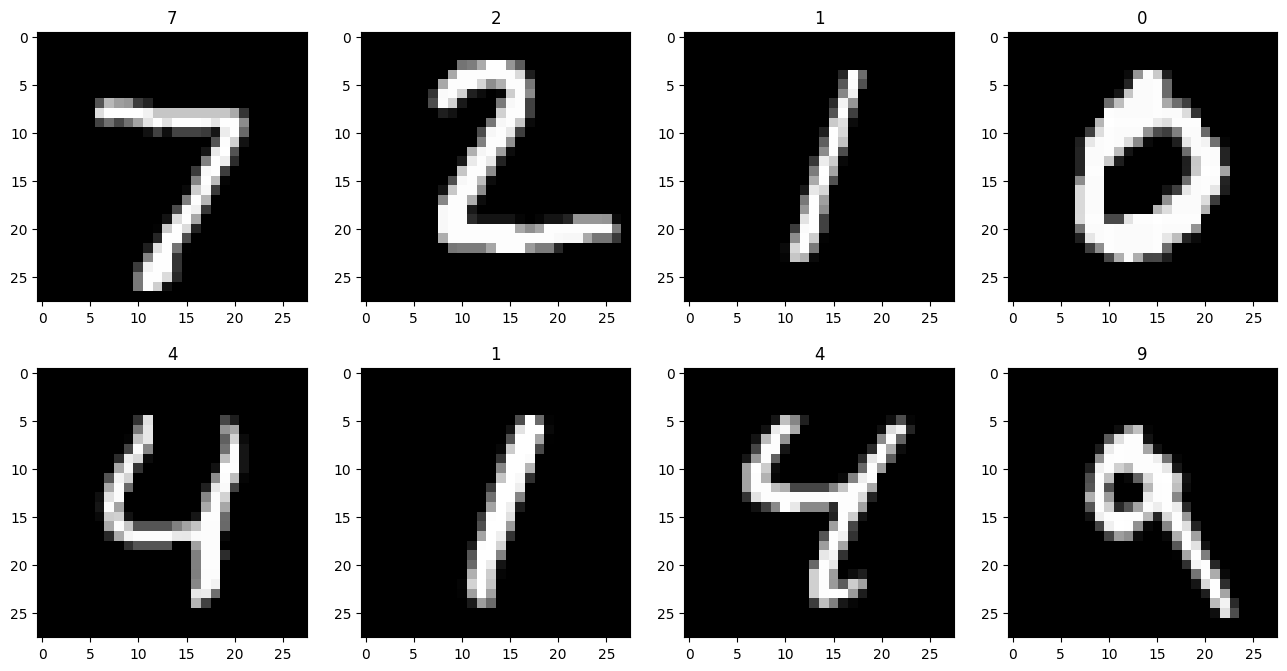

In [35]:
for data in test_loader:
    break

n, k = 4, batch_size_test // 4 + 1 * int((batch_size_test % 4)>0)
images = data[0].cpu().numpy()
labels = data[1].cpu().numpy()
fig, ax = plt.subplots(k, n, figsize=(n*4, 4*k))
for ki in range(k):
    for ni in range(n):
        try:
            im = images[ni + ki*4, 0,  :,:]
            label = labels[ni + ki*4]
            ax[ki, ni].imshow(im)
            ax[ki, ni].set_title(str(label))
        except:
            pass


In [36]:
device = "cuda" if  torch.cuda.is_available() else "cpu"

Нейросеть

Многослойный перцептрон со слоем softmax

In [37]:
class Net(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 8 * hidden_dim)
        self.fc2 = nn.Linear(8 * hidden_dim, 4 * hidden_dim)
        self.fc3 = nn.Linear(4 * hidden_dim, 2 * hidden_dim)
        self.fc4 = nn.Linear(2 * hidden_dim, hidden_dim)
        self.fc5 = nn.Linear(hidden_dim, output_dim)


    def forward(self, x):
        x = x.view(x.shape[0], -1)
        x = self.fc1(x)
        x = F.leaky_relu(x)
        x = self.fc2(x)
        x = F.leaky_relu(x)
        x = self.fc3(x)
        x = F.leaky_relu(x)
        x = self.fc4(x)
        x = F.leaky_relu(x)
        x = self.fc5(x)
        return torch.nn.functional.softmax(x)

mlp = Net(input_dim=28*28,hidden_dim=1, output_dim=10).to(device)
print(mlp)

Net(
  (fc1): Linear(in_features=784, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=4, bias=True)
  (fc3): Linear(in_features=4, out_features=2, bias=True)
  (fc4): Linear(in_features=2, out_features=1, bias=True)
  (fc5): Linear(in_features=1, out_features=10, bias=True)
)


Сверточная нейросеть

In [38]:
class NetC(nn.Module):

    def __init__(self, output_dim, input_dim=1):
        super(NetC, self).__init__()
        self.dp_one = nn.Dropout(0.2)
        self.dp_two = nn.Dropout(0.2)

        self.bn_one = torch.nn.BatchNorm2d(input_dim)
        self.conv_one = torch.nn.Conv2d(input_dim, 30, 3)#30
        self.bn_two = torch.nn.BatchNorm2d(30)
        self.conv_two = torch.nn.Conv2d(30, 60, 3)#
        self.bn_three = torch.nn.BatchNorm2d(60)
        self.conv_three = torch.nn.Conv2d(60, 120, 3)
        self.bn_four = torch.nn.BatchNorm2d(120)
        self.fc1 = torch.nn.Linear(120, 200)
        self.fc2 = torch.nn.Linear(200, 60)
        self.out = torch.nn.Linear(60, output_dim)

    def forward(self, x):
        x = self.bn_one(x)# 28x28x3
        x = self.conv_one(x)#26x26x30
        x = F.relu(x)
        x = F.max_pool2d(x, 2)#30x13x13

        x = self.bn_two(x)
        x = self.conv_two(x)#60 x 11x11
        x = F.relu(x)
        x = F.max_pool2d(x, 2)#60 x 5 x 5

        x = self.bn_three(x)
        x = self.conv_three(x)#120 x 3 x 3
        x = F.leaky_relu(x, 0.1)
        x = F.max_pool2d(x, 2) #120 x 1 x 1

        x = self.bn_four(x)
        x = x.view(x.size(0), -1) # 120 x 1
        x = self.dp_one(x)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dp_two(x)
        x = self.fc2(x)
        x = F.relu(x)
        return self.out(x)

net = NetC(output_dim=10).to(device)
print(net)

NetC(
  (dp_one): Dropout(p=0.2, inplace=False)
  (dp_two): Dropout(p=0.2, inplace=False)
  (bn_one): BatchNorm2d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv_one): Conv2d(1, 30, kernel_size=(3, 3), stride=(1, 1))
  (bn_two): BatchNorm2d(30, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv_two): Conv2d(30, 60, kernel_size=(3, 3), stride=(1, 1))
  (bn_three): BatchNorm2d(60, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv_three): Conv2d(60, 120, kernel_size=(3, 3), stride=(1, 1))
  (bn_four): BatchNorm2d(120, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=120, out_features=200, bias=True)
  (fc2): Linear(in_features=200, out_features=60, bias=True)
  (out): Linear(in_features=60, out_features=10, bias=True)
)


Оптимизатор

In [39]:
# for convoution net
optimizer = torch.optim.Adam(net.parameters(), lr=0.01)
# for MLP
optimizer_mlp = torch.optim.Adam(mlp.parameters(), lr=0.01)

criterion = nn.CrossEntropyLoss()

In [40]:
num_epochs = 5
mlp.train()

for epoch in range(num_epochs):
    running_loss, running_items, running_right = 0.0, 0.0, 0.0
    for i, data in enumerate(train_loader):
        inputs, labels = data[0].to(device), data[1].to(device)

        # обнуляем градиент
        optimizer_mlp.zero_grad()

        outputs = mlp(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_mlp.step()

        # выводим статистику о процессе обучения
        running_loss += loss.item()
        running_items += len(labels)
        running_right += (labels == torch.max(outputs, 1)[1]).sum()

        # выводим статистику о процессе обучения
        if i % 300 == 0:    # печатаем каждые 300 mini-batches
            mlp.eval()

            print(f'Epoch [{epoch + 1}/{num_epochs}]. ' \
                  f'Step [{i + 1}/{len(train_loader)}]. ' \
                  f'Loss: {running_loss / running_items:.3f}. ' \
                  f'Acc: {running_right / running_items:.3f}', end='. ')
            running_loss, running_items, running_right = 0.0, 0.0, 0.0

            test_running_right, test_running_total = 0.0, 0.0
            for i, data in enumerate(test_loader):

                test_outputs = mlp(data[0].to(device))
                test_running_total += len(data[1])
                test_running_right += (data[1].to(device) == torch.max(test_outputs, 1)[1]).sum()

            print(f'Test acc: {test_running_right / test_running_total:.3f}')

        mlp.train()

print('Training is finished!')

/var/folders/q0/6dg0mcx94x77w7989718hdbm0000gn/T/ipykernel_88114/2156362954.py:22: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return torch.nn.functional.softmax(x)


Epoch [1/5]. Step [1/938]. Loss: 0.036. Acc: 0.078. Test acc: 0.096
Epoch [1/5]. Step [301/938]. Loss: 0.034. Acc: 0.261. Test acc: 0.402
Epoch [1/5]. Step [601/938]. Loss: 0.032. Acc: 0.463. Test acc: 0.484
Epoch [1/5]. Step [901/938]. Loss: 0.031. Acc: 0.536. Test acc: 0.578
Epoch [2/5]. Step [1/938]. Loss: 0.031. Acc: 0.516. Test acc: 0.586
Epoch [2/5]. Step [301/938]. Loss: 0.030. Acc: 0.591. Test acc: 0.601
Epoch [2/5]. Step [601/938]. Loss: 0.029. Acc: 0.612. Test acc: 0.621
Epoch [2/5]. Step [901/938]. Loss: 0.029. Acc: 0.628. Test acc: 0.629
Epoch [3/5]. Step [1/938]. Loss: 0.029. Acc: 0.578. Test acc: 0.621
Epoch [3/5]. Step [301/938]. Loss: 0.029. Acc: 0.633. Test acc: 0.629
Epoch [3/5]. Step [601/938]. Loss: 0.029. Acc: 0.644. Test acc: 0.676
Epoch [3/5]. Step [901/938]. Loss: 0.028. Acc: 0.673. Test acc: 0.683
Epoch [4/5]. Step [1/938]. Loss: 0.027. Acc: 0.766. Test acc: 0.680
Epoch [4/5]. Step [301/938]. Loss: 0.028. Acc: 0.694. Test acc: 0.677
Epoch [4/5]. Step [601/938].

In [41]:
inputs.shape

torch.Size([32, 1, 28, 28])

In [42]:
num_epochs = 5
net.train()

for epoch in range(num_epochs):
    running_loss, running_items, running_right = 0.0, 0.0, 0.0
    for i, data in enumerate(train_loader):
        inputs, labels = data[0].to(device), data[1].to(device)

        # обнуляем градиент
        optimizer.zero_grad()

        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # выводим статистику о процессе обучения
        running_loss += loss.item()
        running_items += len(labels)
        running_right += (labels == torch.max(outputs, 1)[1]).sum()

        # выводим статистику о процессе обучения
        if i % 300 == 0:    # печатаем каждые 300 mini-batches
            net.eval()

            print(f'Epoch [{epoch + 1}/{num_epochs}]. ' \
                  f'Step [{i + 1}/{len(train_loader)}]. ' \
                  f'Loss: {running_loss / running_items:.3f}. ' \
                  f'Acc: {running_right / running_items:.3f}', end='. ')
            running_loss, running_items, running_right = 0.0, 0.0, 0.0

            test_running_right, test_running_total = 0.0, 0.0
            for i, data in enumerate(test_loader):

                test_outputs = net(data[0].to(device))
                test_running_total += len(data[1])
                test_running_right += (data[1].to(device) == torch.max(test_outputs, 1)[1]).sum()

            print(f'Test acc: {test_running_right / test_running_total:.3f}')

        mlp.train()

print('Training is finished!')

Epoch [1/5]. Step [1/938]. Loss: 0.036. Acc: 0.156. Test acc: 0.098
Epoch [1/5]. Step [301/938]. Loss: 0.006. Acc: 0.876. Test acc: 0.959
Epoch [1/5]. Step [601/938]. Loss: 0.002. Acc: 0.958. Test acc: 0.963
Epoch [1/5]. Step [901/938]. Loss: 0.002. Acc: 0.964. Test acc: 0.975
Epoch [2/5]. Step [1/938]. Loss: 0.001. Acc: 0.969. Test acc: 0.975
Epoch [2/5]. Step [301/938]. Loss: 0.003. Acc: 0.952. Test acc: 0.964
Epoch [2/5]. Step [601/938]. Loss: 0.002. Acc: 0.969. Test acc: 0.975
Epoch [2/5]. Step [901/938]. Loss: 0.002. Acc: 0.972. Test acc: 0.967
Epoch [3/5]. Step [1/938]. Loss: 0.000. Acc: 1.000. Test acc: 0.980
Epoch [3/5]. Step [301/938]. Loss: 0.001. Acc: 0.980. Test acc: 0.980
Epoch [3/5]. Step [601/938]. Loss: 0.001. Acc: 0.981. Test acc: 0.971
Epoch [3/5]. Step [901/938]. Loss: 0.001. Acc: 0.977. Test acc: 0.977
Epoch [4/5]. Step [1/938]. Loss: 0.000. Acc: 1.000. Test acc: 0.980
Epoch [4/5]. Step [301/938]. Loss: 0.001. Acc: 0.981. Test acc: 0.980
Epoch [4/5]. Step [601/938].

Посмотреть на внутренние слои через дополнительные модели:

- x1 - 1я нормализация
- x2 - 1-я свертка
- x3 - 2-я нормализация
- x4 - 1-й пулинг
- x5 - 3-я свертка

In [43]:
class NetC(nn.Module):

    def __init__(self, output_dim, input_dim=1):
        super(NetC, self).__init__()
        self.dp_one = nn.Dropout(0.2)
        self.dp_two = nn.Dropout(0.2)

        self.bn_one = torch.nn.BatchNorm2d(input_dim)
        self.conv_one = torch.nn.Conv2d(input_dim, 30, 3)#30
        self.bn_two = torch.nn.BatchNorm2d(30)
        self.conv_two = torch.nn.Conv2d(30, 60, 3)#
        self.bn_three = torch.nn.BatchNorm2d(60)
        self.conv_three = torch.nn.Conv2d(60, 120, 3)
        self.bn_four = torch.nn.BatchNorm2d(120)
        self.fc1 = torch.nn.Linear(120, 200)
        self.fc2 = torch.nn.Linear(200, 60)
        self.out = torch.nn.Linear(60, output_dim)

    def forward(self, x):
        x1 = self.bn_one(x)# 28x28x3
        x = x1
        x = self.conv_one(x)#26x26x30
        x = F.relu(x)
        x2 = x
        x = F.max_pool2d(x, 2)#30x13x13
        x4 = x

        x = self.bn_two(x)
        x3 = x
        x = self.conv_two(x)#60 x 11x11
        x = F.relu(x)
        x = F.max_pool2d(x, 2)#60 x 5 x 5

        x = self.bn_three(x)
        x = self.conv_three(x)#120 x 3 x 3
        x = F.leaky_relu(x, 0.1)
        x5 = x
        x = F.max_pool2d(x, 2) #120 x 1 x 1

        x = self.bn_four(x)
        x = x.view(x.size(0), -1) # 120 x 1
        x = self.dp_one(x)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dp_two(x)
        x = self.fc2(x)
        x = F.relu(x)
        return self.out(x), x1, x2, x3, x4, x5

net = NetC(output_dim=10).to(device)
print(net)
optimizer = torch.optim.Adam(net.parameters(), lr=0.01)

NetC(
  (dp_one): Dropout(p=0.2, inplace=False)
  (dp_two): Dropout(p=0.2, inplace=False)
  (bn_one): BatchNorm2d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv_one): Conv2d(1, 30, kernel_size=(3, 3), stride=(1, 1))
  (bn_two): BatchNorm2d(30, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv_two): Conv2d(30, 60, kernel_size=(3, 3), stride=(1, 1))
  (bn_three): BatchNorm2d(60, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv_three): Conv2d(60, 120, kernel_size=(3, 3), stride=(1, 1))
  (bn_four): BatchNorm2d(120, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=120, out_features=200, bias=True)
  (fc2): Linear(in_features=200, out_features=60, bias=True)
  (out): Linear(in_features=60, out_features=10, bias=True)
)


In [44]:
num_epochs = 5
net.train()

for epoch in range(num_epochs):
    running_loss, running_items, running_right = 0.0, 0.0, 0.0
    for i, data in enumerate(train_loader):
        inputs, labels = data[0].to(device), data[1].to(device)

        # обнуляем градиент
        optimizer.zero_grad()

        outputs, _,_,_,_,_ = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # выводим статистику о процессе обучения
        running_loss += loss.item()
        running_items += len(labels)
        running_right += (labels == torch.max(outputs, 1)[1]).sum()

        # выводим статистику о процессе обучения
        if i % 300 == 0:    # печатаем каждые 300 mini-batches
            net.eval()

            print(f'Epoch [{epoch + 1}/{num_epochs}]. ' \
                  f'Step [{i + 1}/{len(train_loader)}]. ' \
                  f'Loss: {running_loss / running_items:.3f}. ' \
                  f'Acc: {running_right / running_items:.3f}', end='. ')
            running_loss, running_items, running_right = 0.0, 0.0, 0.0

            test_running_right, test_running_total = 0.0, 0.0
            for i, data in enumerate(test_loader):

                test_outputs, x1,x2,x3,x4,x5 = net(data[0].to(device))
                test_running_total += len(data[1])
                test_running_right += (data[1].to(device) == torch.max(test_outputs, 1)[1]).sum()

            print(f'Test acc: {test_running_right / test_running_total:.3f}')

        net.train()

print('Training is finished!')

Epoch [1/5]. Step [1/938]. Loss: 0.036. Acc: 0.125. Test acc: 0.103
Epoch [1/5]. Step [301/938]. Loss: 0.004. Acc: 0.918. Test acc: 0.943
Epoch [1/5]. Step [601/938]. Loss: 0.003. Acc: 0.957. Test acc: 0.970
Epoch [1/5]. Step [901/938]. Loss: 0.002. Acc: 0.964. Test acc: 0.973
Epoch [2/5]. Step [1/938]. Loss: 0.002. Acc: 0.984. Test acc: 0.975
Epoch [2/5]. Step [301/938]. Loss: 0.002. Acc: 0.970. Test acc: 0.978
Epoch [2/5]. Step [601/938]. Loss: 0.002. Acc: 0.971. Test acc: 0.978
Epoch [2/5]. Step [901/938]. Loss: 0.002. Acc: 0.973. Test acc: 0.980
Epoch [3/5]. Step [1/938]. Loss: 0.001. Acc: 0.969. Test acc: 0.980
Epoch [3/5]. Step [301/938]. Loss: 0.001. Acc: 0.975. Test acc: 0.980
Epoch [3/5]. Step [601/938]. Loss: 0.002. Acc: 0.974. Test acc: 0.984
Epoch [3/5]. Step [901/938]. Loss: 0.002. Acc: 0.974. Test acc: 0.974
Epoch [4/5]. Step [1/938]. Loss: 0.000. Acc: 1.000. Test acc: 0.981
Epoch [4/5]. Step [301/938]. Loss: 0.001. Acc: 0.979. Test acc: 0.984
Epoch [4/5]. Step [601/938].

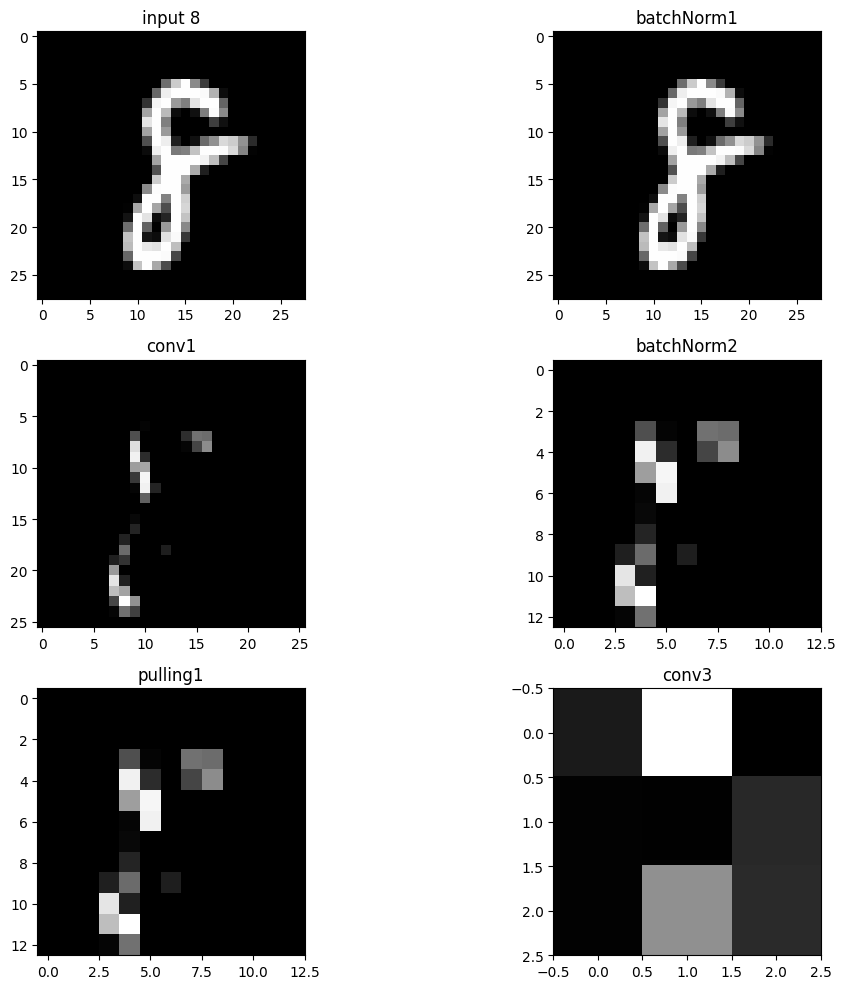

In [45]:
test_outputs, x1,x2,x3,x4,x5 = net(data[0].to(device))
label =  data[1]
m0 =  2

fig = plt.figure(figsize=(12, 10)) # Increased figure size for better spacing

g1 = x1[m0, 0, :, :].cpu().detach().numpy()
plt.subplot(322)
plt.imshow(g1)
plt.title("batchNorm1")

g1 = data[0][m0, 0, :, :].cpu().detach().numpy()
plt.subplot(321)
plt.imshow(g1)
plt.title("input " + str(label[m0].item()))
g1 =  x2[m0, 0, :, :].cpu().detach().numpy()

plt.subplot(323)
plt.imshow(g1)
plt.title("conv1")

g1 =  x3[m0, 0, :, :].cpu().detach().numpy()
plt.subplot(324)
plt.title("batchNorm2")
plt.imshow(g1)

g1 =  x4[m0, 0, :, :].cpu().detach().numpy()
plt.subplot(325)
plt.imshow(g1)
plt.title("pulling1")

g1 =  x5[m0, 0, :, :].cpu().detach().numpy()
plt.subplot(326)
plt.imshow(g1)
plt.title("conv3")
plt.tight_layout() # Automatically adjusts subplot params for a tight layout
plt.show()

In [49]:
transfor_rgb = torchvision.transforms.Compose([transforms.Resize(28),
                                       transforms.ToTensor(),
                                       transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                                            std=[0.229, 0.224, 0.225])])
train_dataset = torchvision.datasets.CIFAR10(root='./data',
                                             train=True,
                                             transform=transfor_rgb,
                                             download=True)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset,
                                           batch_size=64,
                                           shuffle=True)

batch_size_test = 8
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transfor_rgb)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size_test,
                                         shuffle=False)

100%|█████████████████████████████████████████| 170M/170M [03:57<00:00, 716kB/s]


[An Interactive Node-Link Visualization of Convolutional Neural Networks](https://adamharley.com/nn_vis/)

## Задание 1.

1.1 адаптировать модель к набору данных CIFAR10

1.2 провести обучение - получить результаты (создать разные сетки - средний пуллинг, максимальный , стек сверток, включать нормализацию, включать дропаут)

1.3  собрать результаты - сравнить

In [51]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm

In [53]:
def show_image(image, figsize=(10, 10)):
    img_np = inv_normalize(image).permute(1, 2, 0).numpy()
    plt.figure(figsize=figsize)
    plt.imshow(img_np)
    plt.axis('off')
    plt.show()

def inv_normalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    inv_tensor = tensor * std + mean
    inv_tensor = torch.clamp(inv_tensor, 0, 1)
    return inv_tensor

Label: frog


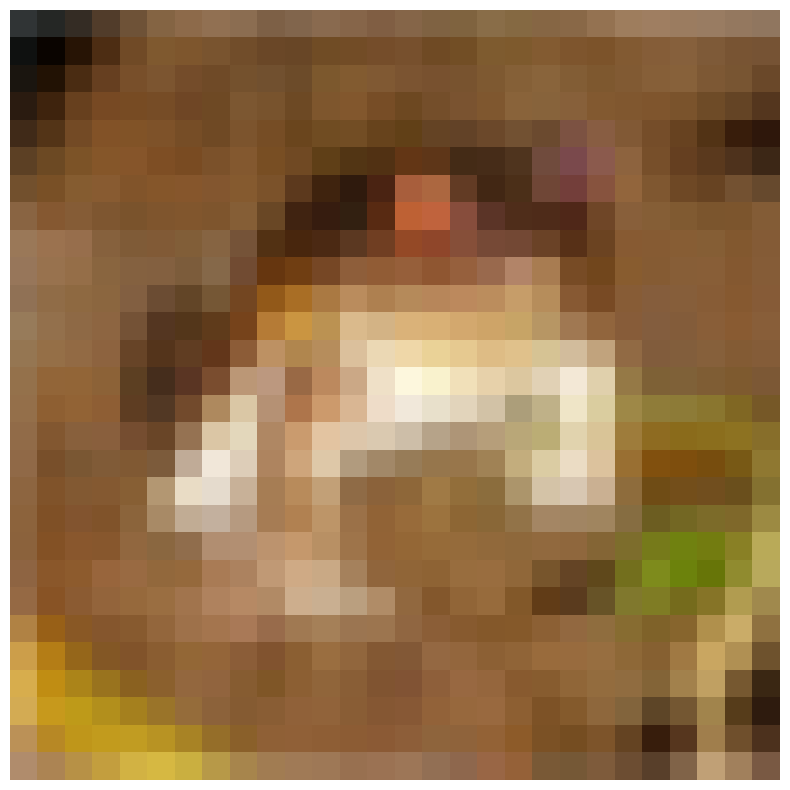

In [63]:
image, label = train_dataset[0]
print(f"Label: {classes[label]}")
show_image(image)

In [52]:
def train_with_logging(model, optimizer, loss_func, train_dataloader, test_dataloader, n_epochs=5, device='cuda'):
    train_losses, train_accuracies = [], []
    test_losses, test_accuracies = [], []
    
    for epoch in range(n_epochs):
        model.train() 
        train_loss_epoch = []
        train_correct = 0
        train_total = 0
        
        for x_train, y_train in tqdm(train_dataloader, desc=f'Epoch {epoch+1}/{n_epochs} [Train]'):
            x_train, y_train = x_train.to(device), y_train.to(device)  
            
            y_pred = model(x_train)
            loss = loss_func(y_pred, y_train)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            
            train_loss_epoch.append(loss.item())
            pred = y_pred.argmax(dim=1, keepdim=True)
            train_correct += pred.eq(y_train.view_as(pred)).sum().item()
            train_total += y_train.size(0)
        
        model.eval()  
        test_loss_epoch = []
        test_correct = 0
        test_total = 0
        
        with torch.no_grad():
            for x_test, y_test in tqdm(test_dataloader, desc=f'Epoch {epoch+1}/{n_epochs} [Test]'):
                x_test, y_test = x_test.to(device), y_test.to(device)  # Переносим на device
                
                y_pred = model(x_test)
                loss = loss_func(y_pred, y_test)
                
                test_loss_epoch.append(loss.item())
                pred = y_pred.argmax(dim=1, keepdim=True)
                test_correct += pred.eq(y_test.view_as(pred)).sum().item()
                test_total += y_test.size(0)
        
        train_losses.append(np.mean(train_loss_epoch))
        train_accuracies.append(train_correct / train_total)
        test_losses.append(np.mean(test_loss_epoch))
        test_accuracies.append(test_correct / test_total)

        print(f'Epoch: {epoch+1}, Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_accuracies[-1]:.4f}, '
              f'Test Loss: {test_losses[-1]:.4f}, Test Acc: {test_accuracies[-1]:.4f}')
    
    return {
        'train_loss': train_losses,
        'train_acc': train_accuracies,
        'test_loss': test_losses,
        'test_acc': test_accuracies
    }

In [64]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model_base = nn.Sequential(
    nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    nn.Flatten(),
    nn.Linear(in_features=64*7*7, out_features=128),
    nn.ReLU(),
    nn.Linear(in_features=128, out_features=10)
).to(device)

model_avg_pool = nn.Sequential(
    nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.AvgPool2d(kernel_size=2),
    nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.AvgPool2d(kernel_size=2),
    nn.Flatten(),
    nn.Linear(in_features=64*7*7, out_features=128),
    nn.ReLU(),
    nn.Linear(in_features=128, out_features=10)
).to(device)

model_batch_norm = nn.Sequential(
    nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
    nn.BatchNorm2d(num_features=32),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
    nn.BatchNorm2d(num_features=64),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    nn.Flatten(),
    nn.Linear(in_features=64*7*7, out_features=128),
    nn.ReLU(),
    nn.Linear(in_features=128, out_features=10)
).to(device)

model_dropout = nn.Sequential(
    nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    nn.Dropout2d(p=0.2),
    nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    nn.Dropout2d(p=0.2),
    nn.Flatten(),
    nn.Linear(in_features=64*7*7, out_features=128),
    nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(in_features=128, out_features=10)
).to(device)

model_more_conv = nn.Sequential(
    nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    nn.Flatten(),
    nn.Linear(in_features=64*7*7, out_features=128),
    nn.ReLU(),
    nn.Linear(in_features=128, out_features=10)
).to(device)

model_batch_norm_dropout = nn.Sequential(
    nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
    nn.BatchNorm2d(num_features=32),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    nn.Dropout2d(p=0.2),
    nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
    nn.BatchNorm2d(num_features=64),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    nn.Dropout2d(p=0.2),
    nn.Flatten(),
    nn.Linear(in_features=64*7*7, out_features=128),
    nn.BatchNorm1d(num_features=128),
    nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(in_features=128, out_features=10)
).to(device)

models = {
    'Base': model_base,
    'AvgPool': model_avg_pool,
    'BatchNorm': model_batch_norm,
    'Dropout': model_dropout,
    'More Conv Layers': model_more_conv,
    'BatchNorm and Dropout': model_batch_norm_dropout
}

In [65]:
criterion = nn.CrossEntropyLoss()
results = {}

for name, model in models.items():
    print(f'training: {name}')    
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    history = train_with_logging(model, optimizer, criterion, train_loader, test_loader, n_epochs=5, device=device)
    results[name] = history

training: Base


Epoch 1/5 [Test]: 100%|████████████████████| 1250/1250 [00:02<00:00, 466.18it/s]


Epoch: 1, Train Loss: 1.3218, Train Acc: 0.5259, Test Loss: 1.0774, Test Acc: 0.6188


Epoch 2/5 [Test]: 100%|████████████████████| 1250/1250 [00:02<00:00, 465.56it/s]


Epoch: 2, Train Loss: 0.9795, Train Acc: 0.6562, Test Loss: 0.9834, Test Acc: 0.6503


...

Epoch: 3, Train Loss: 1.1863, Train Acc: 0.5802, Test Loss: 0.9673, Test Acc: 0.6642


Epoch 4/5 [Test]: 100%|████████████████████| 1250/1250 [00:02<00:00, 452.50it/s]


Epoch: 4, Train Loss: 1.1130, Train Acc: 0.6068, Test Loss: 0.9386, Test Acc: 0.6692


Epoch 5/5 [Test]: 100%|████████████████████| 1250/1250 [00:02<00:00, 450.60it/s]

Epoch: 5, Train Loss: 1.0663, Train Acc: 0.6253, Test Loss: 0.9031, Test Acc: 0.6850


In [68]:
def plot_comparison(results):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    colors = plt.cm.rainbow(np.linspace(0, 1, len(results)))
    
    ax = axes[0]
    for (name, data), color in zip(results.items(), colors):
        epochs = range(1, len(data['test_loss']) + 1)
        ax.plot(epochs, data['test_loss'], label=name, color=color, linewidth=2.5, marker='o', markersize=7)
    
    ax.set_xlabel('Epochs', fontsize=16)
    ax.set_ylabel('Loss', fontsize=16)
    ax.set_title('Test Loss по эпохам', fontsize=18)
    ax.legend(loc='best', fontsize=12)
    ax.grid(True, alpha=0.3)
    
    ax = axes[1]
    for (name, data), color in zip(results.items(), colors):
        epochs = range(1, len(data['test_acc']) + 1)
        ax.plot(epochs, data['test_acc'], label=name, color=color,
               linewidth=2.5, marker='s', markersize=7)
    
    ax.set_xlabel('Epochs', fontsize=16)
    ax.set_ylabel('Accuracy', fontsize=16)
    ax.set_title('Test Accuracy по эпохам', fontsize=18)
    ax.legend(loc='best', fontsize=12)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

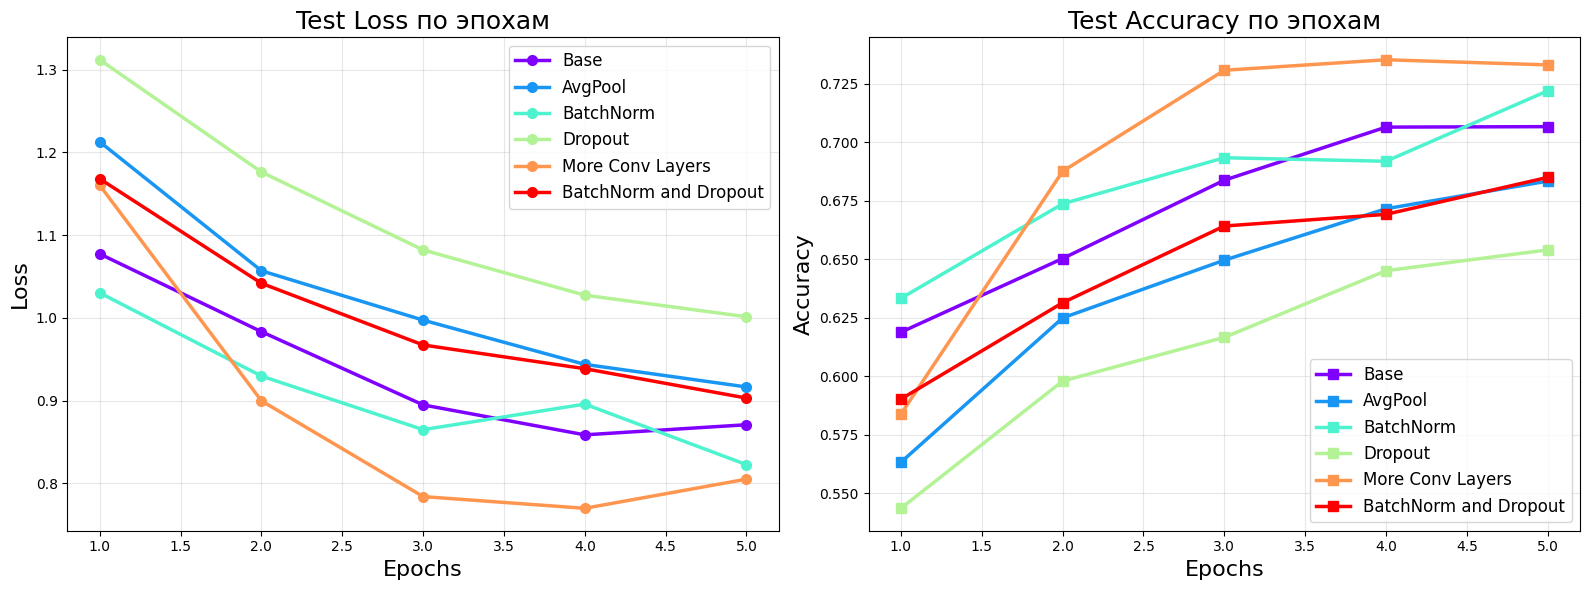

In [69]:
plot_comparison(results)

#### Выводы по выбору CNN модели 

1. Модель с наибольшим числом свёрточных слоёв показывает наилучшее качество.
2. Слишком больше значение вероятности зануления нейрона в Dropout может приводить к недообучению, поэтому модель с Dropout имеет тут самый     слабый результат.
3. AvgPool даёт результат хуже чем MaxPool.
4. BatchNorm улучшает результат.

## Задание 2

2.1 добавить резидуальный обход

2.2 сделать более глубокую сеть

In [70]:
class NetC(nn.Module):

    def __init__(self, output_dim, input_dim=1):
        super(NetC, self).__init__()
        self.dp_one = nn.Dropout(0.2)
        self.dp_two = nn.Dropout(0.2)

        self.bn_one1 = torch.nn.BatchNorm2d(input_dim)
        self.bn_one2 = torch.nn.BatchNorm2d(30)
        self.conv_one1 = torch.nn.Conv2d(input_dim, 30, 3, padding=1)#30
        self.conv_one2 = torch.nn.Conv2d(30, 30, 3)#30
        self.bn_two = torch.nn.BatchNorm2d(30)
        self.conv_two1 = torch.nn.Conv2d(30, 30, 3, padding=1)#
        self.conv_two2 = torch.nn.Conv2d(30, 30, 3, padding=1)
        self.conv_two3 = torch.nn.Conv2d(30, 60, 3)

        self.bn_three = torch.nn.BatchNorm2d(60)
        self.conv_three = torch.nn.Conv2d(60, 120, 3)
        self.bn_four = torch.nn.BatchNorm2d(120)
        self.fc1 = torch.nn.Linear(120, 200)
        self.fc2 = torch.nn.Linear(200, 60)
        self.out = torch.nn.Linear(60, output_dim)

    def forward(self, x):
        x1 = self.bn_one1(x)# 28x28x3
        x = x1
        # стек сверток
        x = self.conv_one1(x)#26x26x30
        x = F.relu(x)

        x = self.conv_one2(x)#26x26x30
        x = F.relu(x)
        x = self.bn_one2(x)

        x2 = x
        x = F.max_pool2d(x, 2)#30x13x13
        x4 = x

        x = self.bn_two(x)
        x3 = x
        x = self.conv_two1(x)#60 x 11x11
        x = F.relu(x)
        x = self.conv_two2(x)#60 x 11x11
        x = F.relu(x)
        x = x + x3 # резидуальный обход
        x = self.conv_two3(x)#60 x 11x11
        x = F.relu(x)
        x = F.max_pool2d(x, 2)#60 x 5 x 5

        x = self.bn_three(x)
        x = self.conv_three(x)#120 x 3 x 3
        x = F.leaky_relu(x, 0.1)
        x5 = x
        x = F.max_pool2d(x, 2) #120 x 1 x 1

        x = self.bn_four(x)
        x = x.view(x.size(0), -1) # 120 x 1

        x = self.dp_one(x)
        # print(x.shape)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dp_two(x)
        x = self.fc2(x)
        x = F.relu(x)
        return self.out(x), x1, x2, x3, x4, x5

net = NetC(output_dim=10, input_dim=3).to(device)
print(net)
optimizer = torch.optim.Adam(net.parameters(), lr=0.01)

NetC(
  (dp_one): Dropout(p=0.2, inplace=False)
  (dp_two): Dropout(p=0.2, inplace=False)
  (bn_one1): BatchNorm2d(3, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn_one2): BatchNorm2d(30, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv_one1): Conv2d(3, 30, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv_one2): Conv2d(30, 30, kernel_size=(3, 3), stride=(1, 1))
  (bn_two): BatchNorm2d(30, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv_two1): Conv2d(30, 30, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv_two2): Conv2d(30, 30, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv_two3): Conv2d(30, 60, kernel_size=(3, 3), stride=(1, 1))
  (bn_three): BatchNorm2d(60, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv_three): Conv2d(60, 120, kernel_size=(3, 3), stride=(1, 1))
  (bn_four): BatchNorm2d(120, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1

In [72]:
class NetCWrapper(nn.Module):
    def __init__(self, output_dim, input_dim=3):
        super(NetCWrapper, self).__init__()
        self.net = NetC(output_dim, input_dim)
    
    def forward(self, x):
        output, _, _, _, _, _ = self.net(x)
        return output

### Что такое Residual Connection?

Суть резидуального обхода заключается в том, что вход слоя или группы слоев напрямую добавляется к выходу этих слоев. Формально, если у нас есть функция $H(x)$, которую слой или блок пытается аппроксимировать, то вместо прямого изучения $H(x)$, блок изучает *резидуум* $F(x) = H(x) - x$. Таким образом, выход блока будет $H(x) = F(x) + x$.

Графически это выглядит как стрелка, которая 'обходит' один или несколько слоев, соединяя вход с выходом, прежде чем результат проходит через функцию активации.

### Зачем нужны Residual Connections?

1.  **Решение проблемы затухания/взрыва градиентов (Vanishing/Exploding Gradients)**: В очень глубоких сетях градиенты при обратном распространении могут либо затухать до нуля, либо взрываться, что делает обучение сети очень сложным. Резидуальные обходы обеспечивают прямой путь для градиентов, позволяя им свободно проходить через сеть и эффективно обновлять веса.

2.  **Облегчение обучения глубоких сетей**: Без резидуальных обходов добавление большего количества слоев в глубокую сеть может привести к ухудшению производительности (даже на обучающей выборке), а не к ее улучшению. Это связано с тем, что оптимизатору становится труднее изучать функцию тождественности (identity function) для дополнительных слоев (т.е., чтобы новые слои просто пропускали вход без изменений). С резидуальным обходом, если новые слои ничего не улучшают, они могут просто изучить $F(x) = 0$, и тогда $H(x) = x$, что гораздо проще.

3.  **Повышение производительности**: За счет более эффективного обучения, сети с резидуальными обходами часто достигают лучшей производительности на различных задачах, особенно в компьютерном зрении.

### Как это выглядит в коде (пример из ноутбука):

В предоставленном коде вы можете увидеть резидуальный обход в классе `NetC`:

```python
        x = self.bn_two(x)
        x3 = x # Сохраняем вход для резидуального обхода
        x = self.conv_two1(x)
        x = F.relu(x)
        x = self.conv_two2(x)
        x = F.relu(x)
        x = x + x3 # Здесь происходит добавление входа (x3) к выходу слоев
        x = self.conv_two3(x)
```

Здесь `x3` сохраняет состояние тензора перед блоком сверток (`conv_two1`, `conv_two2`). После прохождения через эти сверточные слои и активации, оригинальный `x3` добавляется к их выходу (`x = x + x3`), что и является резидуальным обходом.

In [73]:
model_residual = NetCWrapper(output_dim=10, input_dim=3).to(device)

optimizer = torch.optim.Adam(model_residual.parameters(), lr=0.001)
history_residual = train_with_logging(model_residual, optimizer, criterion, train_loader, test_loader, n_epochs=5, device=device)

Epoch 1/5 [Test]: 100%|████████████████████| 1250/1250 [00:04<00:00, 264.28it/s]


Epoch: 1, Train Loss: 1.3933, Train Acc: 0.4912, Test Loss: 1.0912, Test Acc: 0.6118


Epoch 2/5 [Test]: 100%|████████████████████| 1250/1250 [00:04<00:00, 268.75it/s]


Epoch: 2, Train Loss: 1.0236, Train Acc: 0.6410, Test Loss: 0.9250, Test Acc: 0.6750


Epoch 3/5 [Test]: 100%|████████████████████| 1250/1250 [00:04<00:00, 274.18it/s]


Epoch: 3, Train Loss: 0.8692, Train Acc: 0.6940, Test Loss: 0.8452, Test Acc: 0.7083


Epoch 4/5 [Test]: 100%|████████████████████| 1250/1250 [00:04<00:00, 267.08it/s]


Epoch: 4, Train Loss: 0.7815, Train Acc: 0.7291, Test Loss: 0.8090, Test Acc: 0.7237


Epoch 5/5 [Test]: 100%|████████████████████| 1250/1250 [00:04<00:00, 271.11it/s]

Epoch: 5, Train Loss: 0.7164, Train Acc: 0.7519, Test Loss: 0.7626, Test Acc: 0.7420


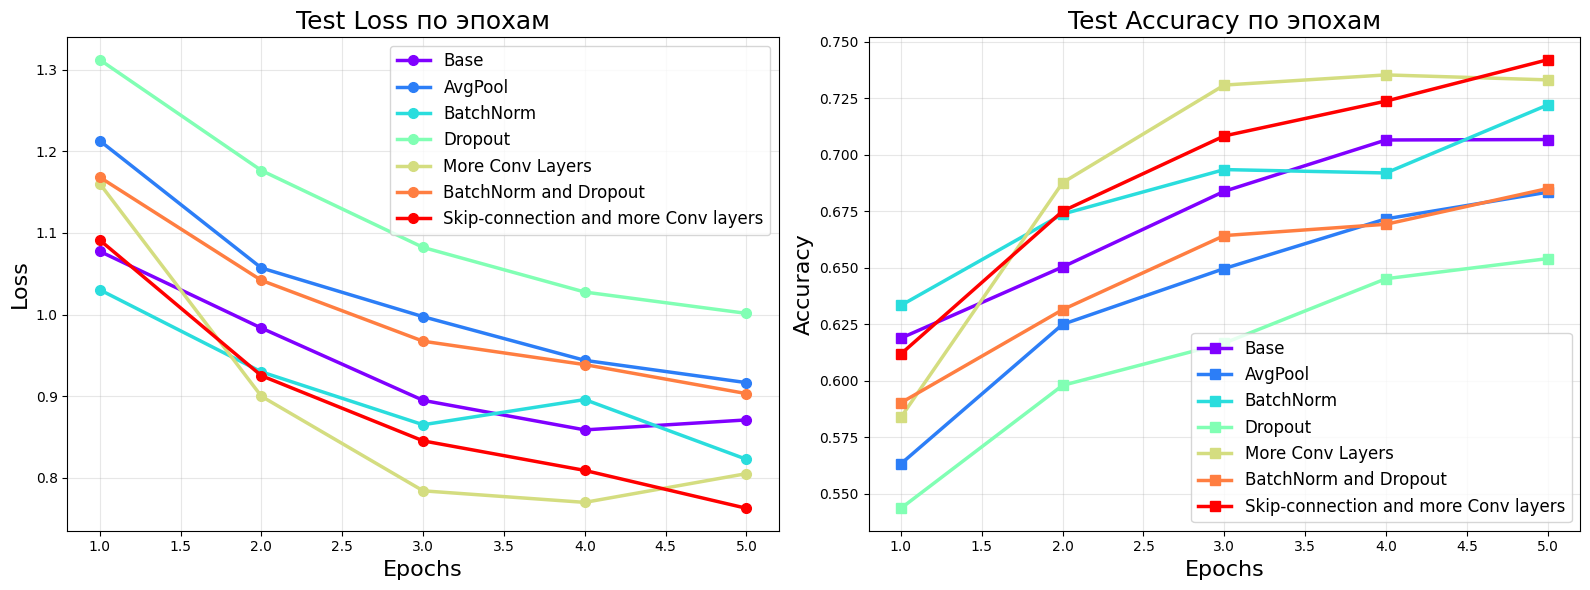

In [74]:
results["Skip-connection and more Conv layers"] = history_residual
plot_comparison(results)

Skip-Connection в сочетании с большим числом слоёв даёт наилучший результат.

## Аугментация





In [75]:
batch_size_test = 8
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transfor_rgb)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size_test,
                                         shuffle=False)

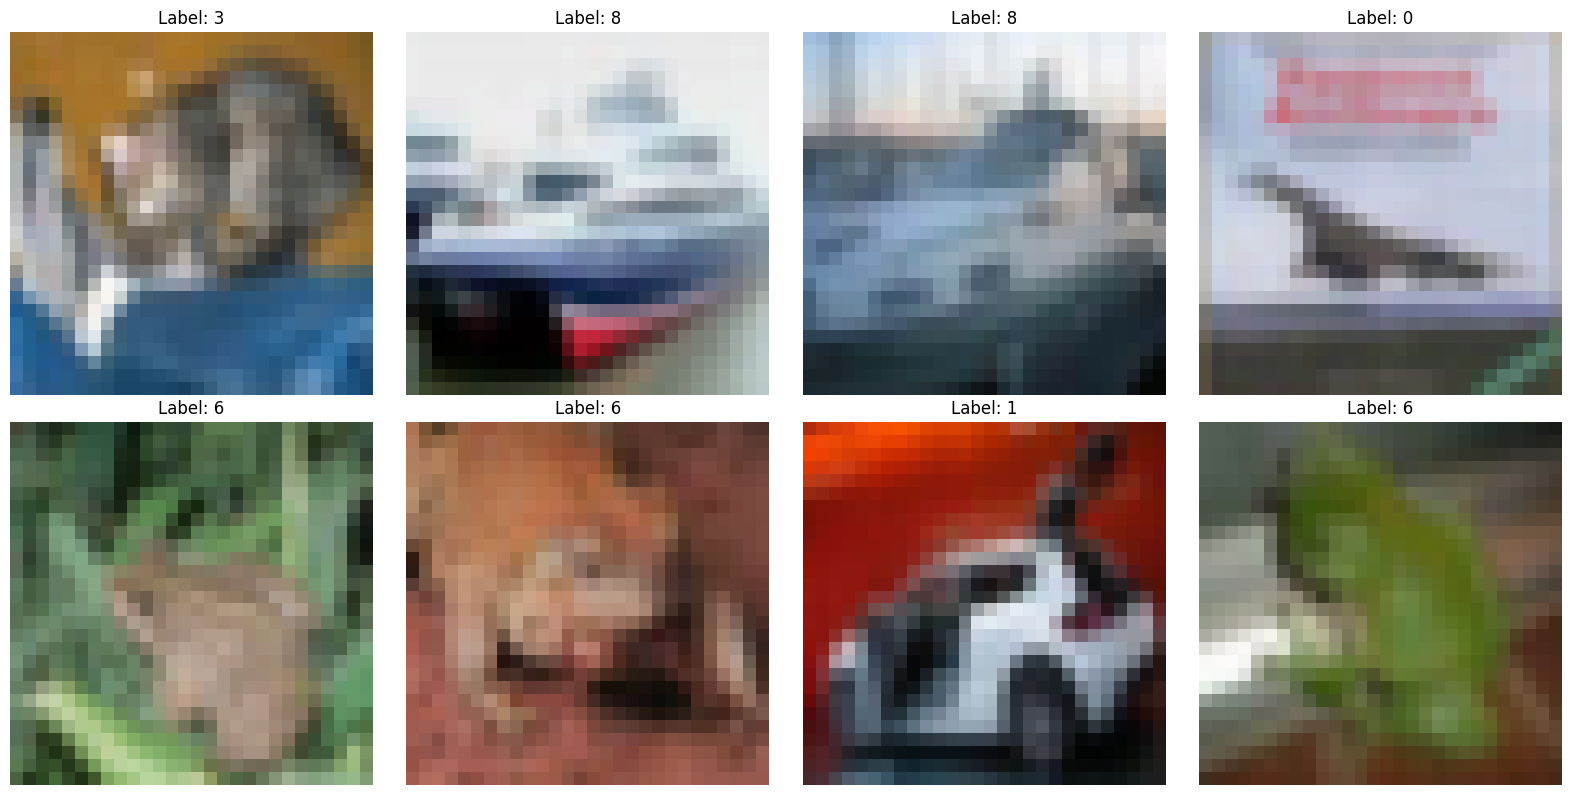

In [77]:
for data in test_loader:
    break

n, k = 4, batch_size_test // 4 + 1 * int((batch_size_test % 4) > 0)
images = data[0].cpu().numpy()
labels = data[1].cpu().numpy()

fig, ax = plt.subplots(k, n, figsize=(n*4, 4*k))

for ki in range(k):
    for ni in range(n):
        try:
            idx = ni + ki * 4
            im = images[idx].transpose(1, 2, 0)
            
            mean = np.array([0.485, 0.456, 0.406])
            std = np.array([0.229, 0.224, 0.225])
            im = im * std + mean
            im = np.clip(im, 0, 1)  
            
            label = labels[idx]
            
            ax[ki, ni].imshow(im)
            ax[ki, ni].set_title(f'Label: {label}')
            ax[ki, ni].axis('off')
        except:
            pass

plt.tight_layout()
plt.show()


In [78]:
transfor_rgb = torchvision.transforms.Compose([transforms.Resize(224),
                                               transforms.RandomPerspective(distortion_scale=0.6, p=0.50),

                                       transforms.ToTensor(),
                                       transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                                            std=[0.229, 0.224, 0.225])])
batch_size_test = 8
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transfor_rgb)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size_test,
                                         shuffle=False)

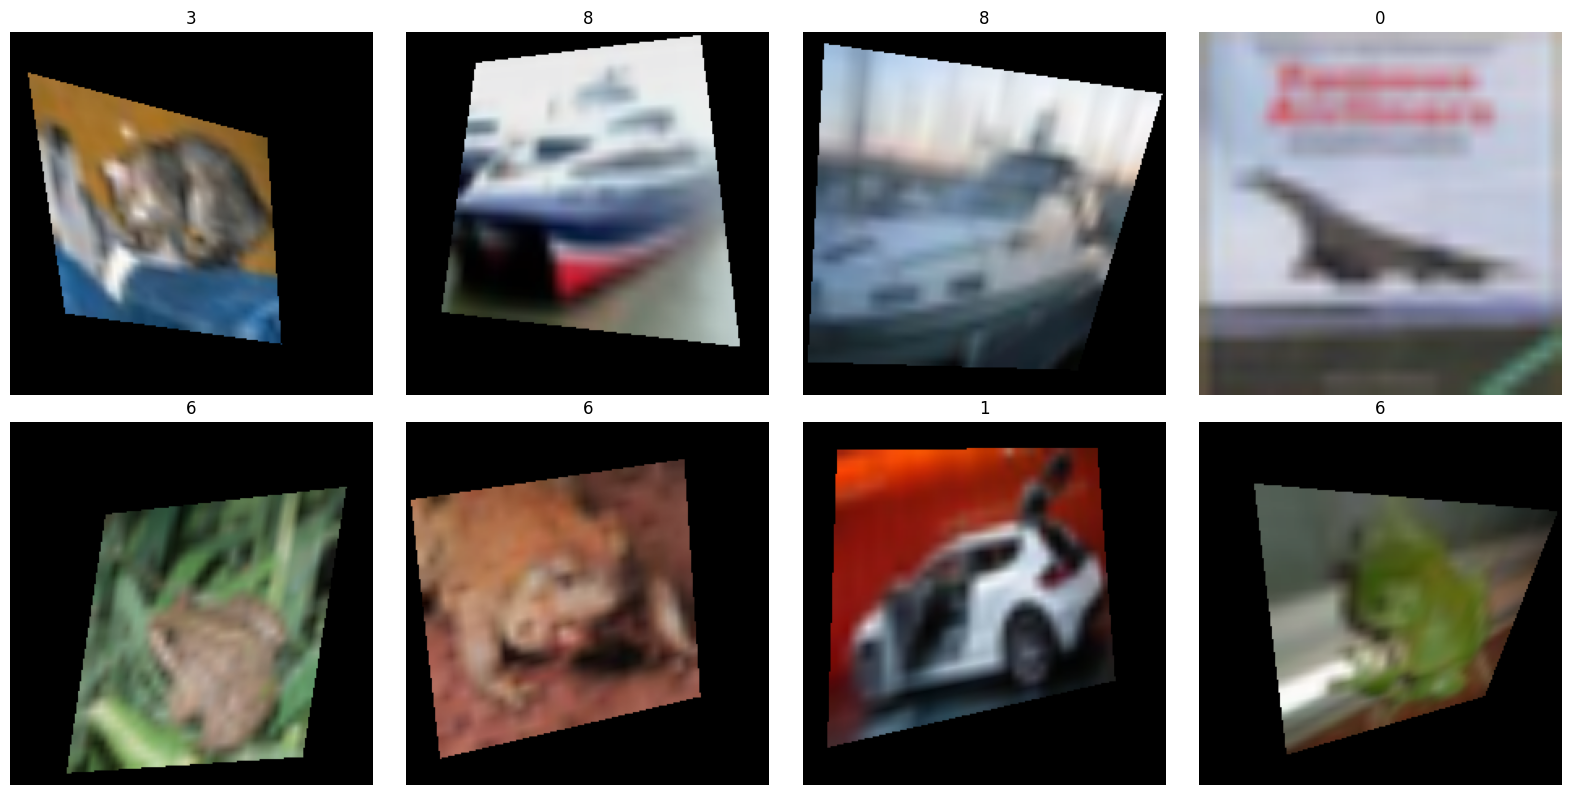

In [79]:
for data in test_loader:
    break

n, k = 4, batch_size_test // 4 + 1 * int((batch_size_test % 4) > 0)
images = data[0].cpu().numpy()
labels = data[1].cpu().numpy()

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

fig, ax = plt.subplots(k, n, figsize=(n*4, 4*k))

for ki in range(k):
    for ni in range(n):
        try:
            idx = ni + ki * 4
            im = images[idx].transpose(1, 2, 0)
            
            im = im * std + mean
            im = np.clip(im, 0, 1) 
            
            label = labels[idx]
            ax[ki, ni].imshow(im)
            ax[ki, ni].set_title(str(label))
            ax[ki, ni].axis('off')
        except:
            pass

plt.tight_layout()
plt.show()

## Задание 3

3.1. Сделать аугментации данных

3.2. провести обучение на аугментированных данных

Были добавлены аугментации:

In [81]:
transform_train_aug = transforms.Compose([
    transforms.RandomRotation((-15, 15)),
    transforms.RandomAffine(degrees=0, translate=(0.06, 0.06)),
    transforms.RandomHorizontalFlip(p=0.5),  
    transforms.Resize(28),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x + torch.normal(0, 0.02, size=tuple(x.data.shape))),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_test = transforms.Compose([
    transforms.Resize(28),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset_aug = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    transform=transform_train_aug,
    download=False
)

test_dataset_aug = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    transform=transform_test,
    download=False
)

train_loader_aug = torch.utils.data.DataLoader(
    dataset=train_dataset_aug,
    batch_size=64,
    shuffle=True
)

test_loader_aug = torch.utils.data.DataLoader(
    dataset=test_dataset_aug,
    batch_size=8,
    shuffle=False
)

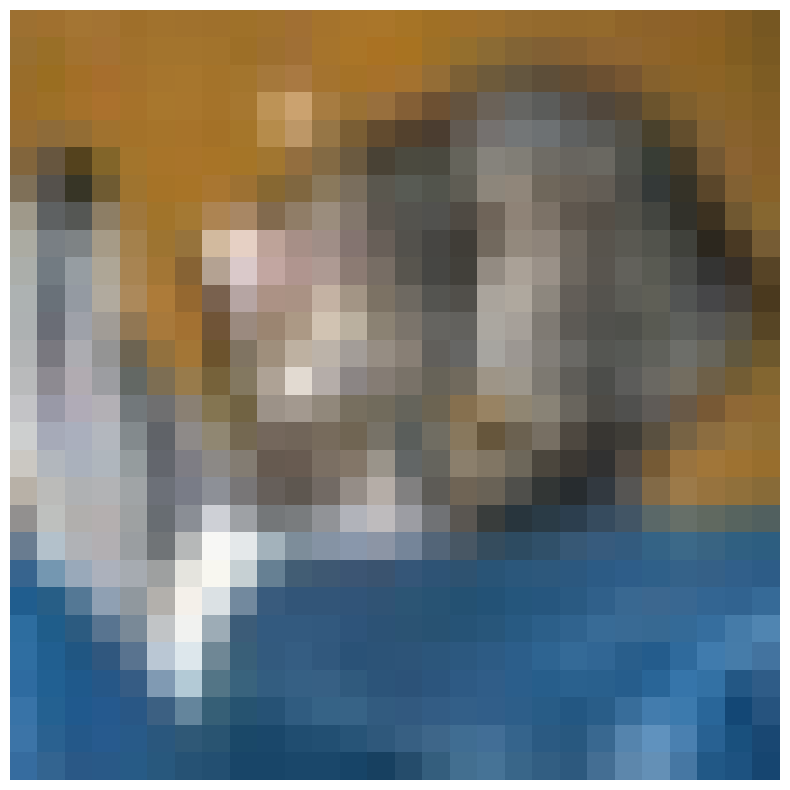

In [140]:
image, _ = test_dataset_aug[0]
show_image(image)

In [82]:
class NetAugmentations(nn.Module):
    def __init__(self, output_dim=10, input_dim=3):
        super(NetAugmentations, self).__init__()
        
        self.bn1_input = nn.BatchNorm2d(input_dim)  # 28x28x3
        self.conv1_1 = nn.Conv2d(in_channels=input_dim, out_channels=32, kernel_size=3, padding=1)  # 28x28x32
        self.bn1_1 = nn.BatchNorm2d(32)
        self.conv1_2 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1) # 28x28x32
        self.bn1_2 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=2) # 14x14x32
        self.dropout1 = nn.Dropout2d(p=0.2)
        
        self.skip1 = nn.Conv2d(in_channels=input_dim, out_channels=32, kernel_size=1)
        
        self.conv2_1 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1) # 14x14x64
        self.bn2_1 = nn.BatchNorm2d(64)
        self.conv2_2 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1) # 14x14x64
        self.bn2_2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2) # 7x7x64
        self.dropout2 = nn.Dropout2d(p=0.2)
        
        self.skip2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=1)
        
        self.conv3_1 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1) # 7x7x128
        self.bn3_1 = nn.BatchNorm2d(128)
        self.conv3_2 = nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1) # 7x7x128
        self.bn3_2 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(kernel_size=2) # 3x3x128
        self.dropout3 = nn.Dropout2d(p=0.2)
        
        self.skip3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=1)
        
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(in_features=128*3*3, out_features=256)
        self.bn_fc1 = nn.BatchNorm1d(256)
        self.dropout_fc = nn.Dropout(p=0.3)
        self.fc2 = nn.Linear(in_features=256, out_features=128)
        self.fc3 = nn.Linear(in_features=128, out_features=output_dim)
    
    def forward(self, x):
        x = self.bn1_input(x)                   
        identity1 = self.skip1(x)               
        
        x = F.relu(self.bn1_1(self.conv1_1(x))) 
        x = F.relu(self.bn1_2(self.conv1_2(x)))
        x = x + identity1                       
        x = self.pool1(x)                       
        x = self.dropout1(x)
        
        identity2 = self.skip2(x)              
        
        x = F.relu(self.bn2_1(self.conv2_1(x))) 
        x = F.relu(self.bn2_2(self.conv2_2(x))) 
        x = x + identity2                        
        x = self.pool2(x)                        
        x = self.dropout2(x)
        
        identity3 = self.skip3(x)               
        
        x = F.relu(self.bn3_1(self.conv3_1(x))) 
        x = F.relu(self.bn3_2(self.conv3_2(x))) 
        x = x + identity3                       
        x = self.pool3(x)                        
        x = self.dropout3(x)
        
        x = self.flatten(x)                      
        x = F.relu(self.bn_fc1(self.fc1(x)))   
        x = self.dropout_fc(x)
        x = F.relu(self.fc2(x))                 
        x = self.fc3(x)                         
        
        return x

In [84]:
model = NetAugmentations(output_dim=10, input_dim=3).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [85]:
history_aug = train_with_logging(model, optimizer, criterion, train_loader_aug, test_loader_aug, n_epochs=5, device=device)

Epoch 1/5 [Test]: 100%|████████████████████| 1250/1250 [00:08<00:00, 147.64it/s]


Epoch: 1, Train Loss: 1.5280, Train Acc: 0.4393, Test Loss: 1.1285, Test Acc: 0.5921


Epoch 2/5 [Test]: 100%|████████████████████| 1250/1250 [00:08<00:00, 147.34it/s]


Epoch: 2, Train Loss: 1.2202, Train Acc: 0.5626, Test Loss: 0.9596, Test Acc: 0.6604


Epoch 3/5 [Test]: 100%|████████████████████| 1250/1250 [00:08<00:00, 145.52it/s]


Epoch: 3, Train Loss: 1.0852, Train Acc: 0.6135, Test Loss: 0.8201, Test Acc: 0.7122


Epoch 4/5 [Test]: 100%|████████████████████| 1250/1250 [00:08<00:00, 150.32it/s]


Epoch: 4, Train Loss: 0.9956, Train Acc: 0.6480, Test Loss: 0.7682, Test Acc: 0.7292


Epoch 5/5 [Test]: 100%|████████████████████| 1250/1250 [00:08<00:00, 146.92it/s]

Epoch: 5, Train Loss: 0.9347, Train Acc: 0.6704, Test Loss: 0.7079, Test Acc: 0.7525


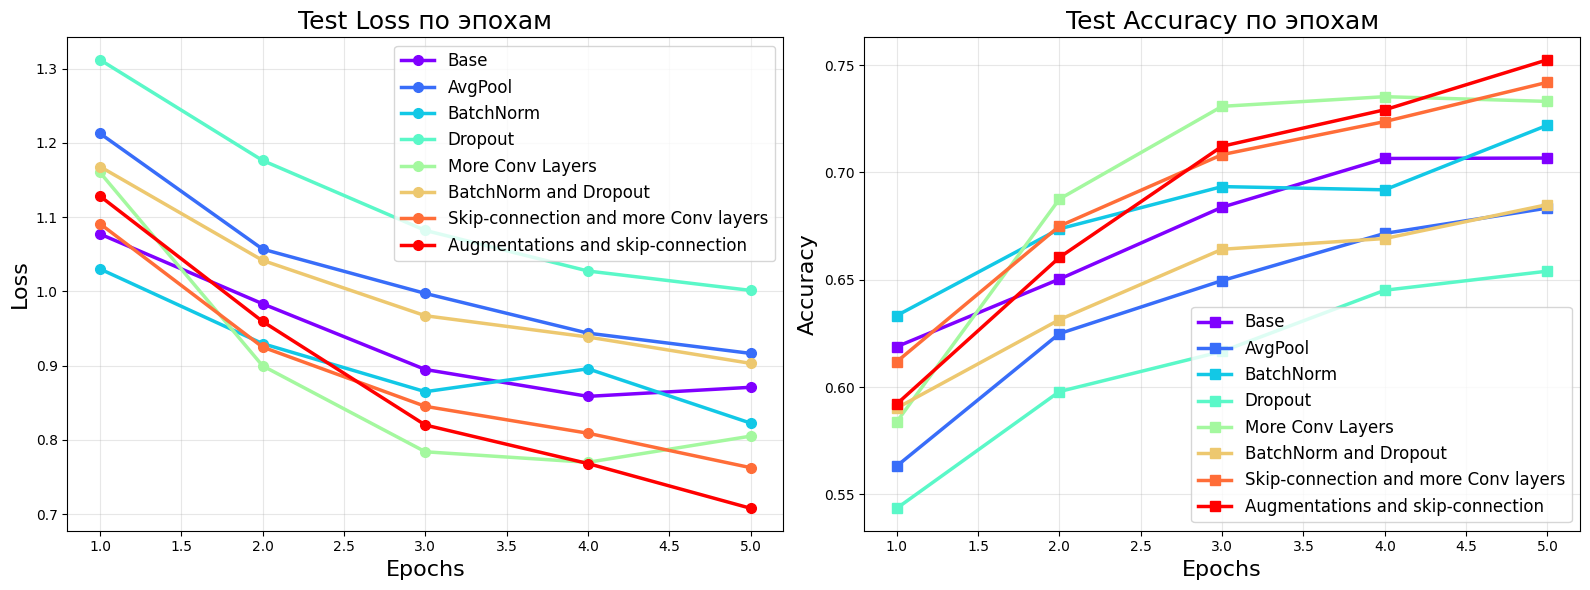

In [86]:
results["Augmentations and skip-connection"] = history_aug
plot_comparison(results)

И снова смогли улучшить предыдущий результат


## Резюме

- Свертка определяет локальные окрестности
- Пулинг агрегирует локальные окрестности


## Домашнее задание

База

  1. в обучить нейронный сверточный классификатор (3 сверточных слоя с ядром kxk (relu), MaxPooling((2,2)), полносвязный слой 100 нейронов (relu), выходной слой softMax - 10 нейронов) на  fasion-mnist и посмотреть как будет изменяться результат обработки для ядра 3х3, 5х5 с визуализацией выходов каждого слоя (для одного примера).
  2. Оценить размеры выходов в режиме padding=1, 2.

*
  1. Предложить постановку задачи, где слой усреднения может работать лучше , чем слой максимизации


  Ссылки:




In [91]:
transform_fashion = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) 
])

train_dataset_fashion = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    transform=transform_fashion,
    download=True
)

test_dataset_fashion = torchvision.datasets.FashionMNIST(
    root='./data',
    train=False,
    transform=transform_fashion,
    download=True
)

train_loader_fashion = torch.utils.data.DataLoader(
    dataset=train_dataset_fashion,
    batch_size=64,
    shuffle=True
)

test_loader_fashion = torch.utils.data.DataLoader(
    dataset=test_dataset_fashion,
    batch_size=8,
    shuffle=False
)

fashion_classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

Label: Ankle boot


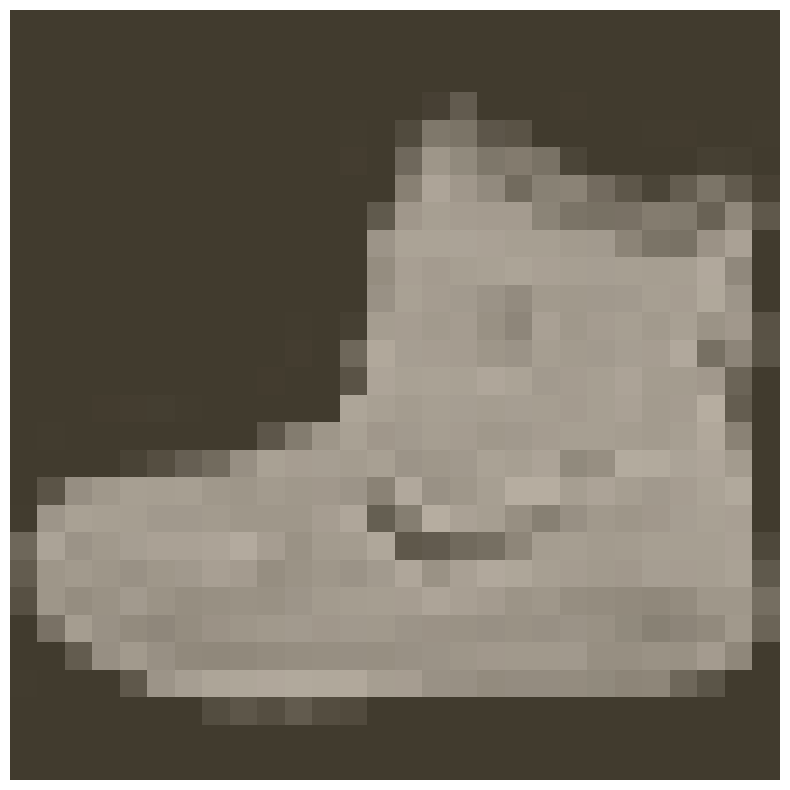

In [97]:
image, label = train_dataset_fashion[0]
print(f"Label: {fashion_classes[label]}")
show_image(image)

In [98]:
image.shape

torch.Size([1, 28, 28])

In [107]:
class FashionCNN(nn.Module):
    def __init__(self, kernel_size=3, padding=1):
        super(FashionCNN, self).__init__()
        
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=kernel_size, padding=padding)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=kernel_size, padding=padding)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=kernel_size, padding=padding)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.fc1 = None  
        self.fc2 = nn.Linear(100, 10)
    
    def forward(self, x, return_intermediates=False):
        x_input = x
        
        x = self.conv1(x)
        x_conv1 = x
        x = F.relu(x)
        x_relu1 = x
        x = self.pool1(x)
        x_pool1 = x
        
        x = self.conv2(x)
        x_conv2 = x
        x = F.relu(x)
        x_relu2 = x
        x = self.pool2(x)
        x_pool2 = x
        
        x = self.conv3(x)
        x_conv3 = x
        x = F.relu(x)
        x_relu3 = x
        x = self.pool3(x)
        x_pool3 = x
        
        x = x.view(x.size(0), -1)
        
        if self.fc1 is None:
            self.fc1 = nn.Linear(x.size(1), 100).to(x.device)
        
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        
        if return_intermediates:
            return x, {
                'input': x_input,
                'conv1': x_conv1,
                'relu1': x_relu1,
                'pool1': x_pool1,
                'conv2': x_conv2,
                'relu2': x_relu2,
                'pool2': x_pool2,
                'conv3': x_conv3,
                'relu3': x_relu3,
                'pool3': x_pool3
            }
        else:
            return x  

In [132]:
def visualize_layer_outputs(model, image, label, device='cuda'):
    model.eval()
    
    with torch.no_grad():
        image_batch = image.unsqueeze(0).to(device)
        output, intermediates = model(image_batch, return_intermediates=True)
        pred = output.argmax(dim=1).item()
    
    fig, axes = plt.subplots(2, 5, figsize=(22, 10))
    axes = axes.ravel()
    
    idx = 0
    
    img = intermediates['input'][idx, 0].cpu().numpy()
    axes[0].imshow(img, cmap='gray')
    axes[0].set_title(f'Input:\n{fashion_classes[label]}', fontsize=14)
    axes[0].axis('off')
    
    img = intermediates['conv1'][idx, 0].cpu().numpy()
    axes[1].imshow(img, cmap='viridis')
    axes[1].set_title(f'Conv1: {intermediates["conv1"].shape}', fontsize=14)
    axes[1].axis('off')
    
    img = intermediates['relu1'][idx, 0].cpu().numpy()
    axes[2].imshow(img, cmap='viridis')
    axes[2].set_title(f'ReLU1: {intermediates["relu1"].shape}', fontsize=14)
    axes[2].axis('off')
    
    img = intermediates['pool1'][idx, 0].cpu().numpy()
    axes[3].imshow(img, cmap='viridis')
    axes[3].set_title(f'Pool1: {intermediates["pool1"].shape}', fontsize=14)
    axes[3].axis('off')
    
    img = intermediates['conv2'][idx, 0].cpu().numpy()
    axes[4].imshow(img, cmap='viridis')
    axes[4].set_title(f'Conv2: {intermediates["conv2"].shape}', fontsize=14)
    axes[4].axis('off')
    
    img = intermediates['relu2'][idx, 0].cpu().numpy()
    axes[5].imshow(img, cmap='viridis')
    axes[5].set_title(f'ReLU2: {intermediates["relu2"].shape}', fontsize=14)
    axes[5].axis('off')
    
    img = intermediates['pool2'][idx, 0].cpu().numpy()
    axes[6].imshow(img, cmap='viridis')
    axes[6].set_title(f'Pool2: {intermediates["pool2"].shape}', fontsize=14)
    axes[6].axis('off')
    
    img = intermediates['conv3'][idx, 0].cpu().numpy()
    axes[7].imshow(img, cmap='viridis')
    axes[7].set_title(f'Conv3: {intermediates["conv3"].shape}', fontsize=14)
    axes[7].axis('off')
    
    img = intermediates['relu3'][idx, 0].cpu().numpy()
    axes[8].imshow(img, cmap='viridis')
    axes[8].set_title(f'ReLU3: {intermediates["relu3"].shape}', fontsize=14)
    axes[8].axis('off')
    
    img = intermediates['pool3'][idx, 0].cpu().numpy()
    axes[9].imshow(img, cmap='viridis')
    axes[9].set_title(f'Pool3: {intermediates["pool3"].shape}', fontsize=14)
    axes[9].axis('off')
    
    fig.suptitle(f'Kernel: {model.conv1.kernel_size[0]}x{model.conv1.kernel_size[0]}. '
                 f'Padding: {model.conv1.padding[0]}. '
                 f'Prediction: {fashion_classes[pred]}', 
                 fontsize=17, y=0.99)
    
    plt.subplots_adjust(top=0.93, hspace=0.4)
    plt.show()

In [111]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
criterion = nn.CrossEntropyLoss()

fashion_results = {}

configs = [
    {'kernel_size': 3, 'padding': 1, 'name': 'Kernel 3x3, Padding 1'},
    {'kernel_size': 3, 'padding': 2, 'name': 'Kernel 3x3, Padding 2'},
    {'kernel_size': 5, 'padding': 1, 'name': 'Kernel 5x5, Padding 1'},
    {'kernel_size': 5, 'padding': 2, 'name': 'Kernel 5x5, Padding 2'},
]

In [112]:
for config in configs:
    print(f"training: {config['name']}")
    
    model = FashionCNN(kernel_size=config['kernel_size'], padding=config['padding']).to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    
    history = train_with_logging(
        model, optimizer, criterion,
        train_loader_fashion, test_loader_fashion,
        n_epochs=5, device=device
    )
    
    fashion_results[config['name']] = {
        'history': history,
        'model': model,
        'config': config
    }

training: Kernel 3x3, Padding 1


Epoch 1/5 [Test]: 100%|████████████████████| 1250/1250 [00:02<00:00, 537.81it/s]


Epoch: 1, Train Loss: 0.5411, Train Acc: 0.8050, Test Loss: 0.4162, Test Acc: 0.8459


Epoch 2/5 [Test]: 100%|████████████████████| 1250/1250 [00:02<00:00, 518.59it/s]


Epoch: 2, Train Loss: 0.3419, Train Acc: 0.8758, Test Loss: 0.3272, Test Acc: 0.8807


...

Epoch: 3, Train Loss: 0.2491, Train Acc: 0.9092, Test Loss: 0.2781, Test Acc: 0.9026


Epoch 4/5 [Test]: 100%|████████████████████| 1250/1250 [00:04<00:00, 298.80it/s]


Epoch: 4, Train Loss: 0.2148, Train Acc: 0.9214, Test Loss: 0.2488, Test Acc: 0.9112


Epoch 5/5 [Test]: 100%|████████████████████| 1250/1250 [00:04<00:00, 300.54it/s]

Epoch: 5, Train Loss: 0.1900, Train Acc: 0.9301, Test Loss: 0.2530, Test Acc: 0.9080


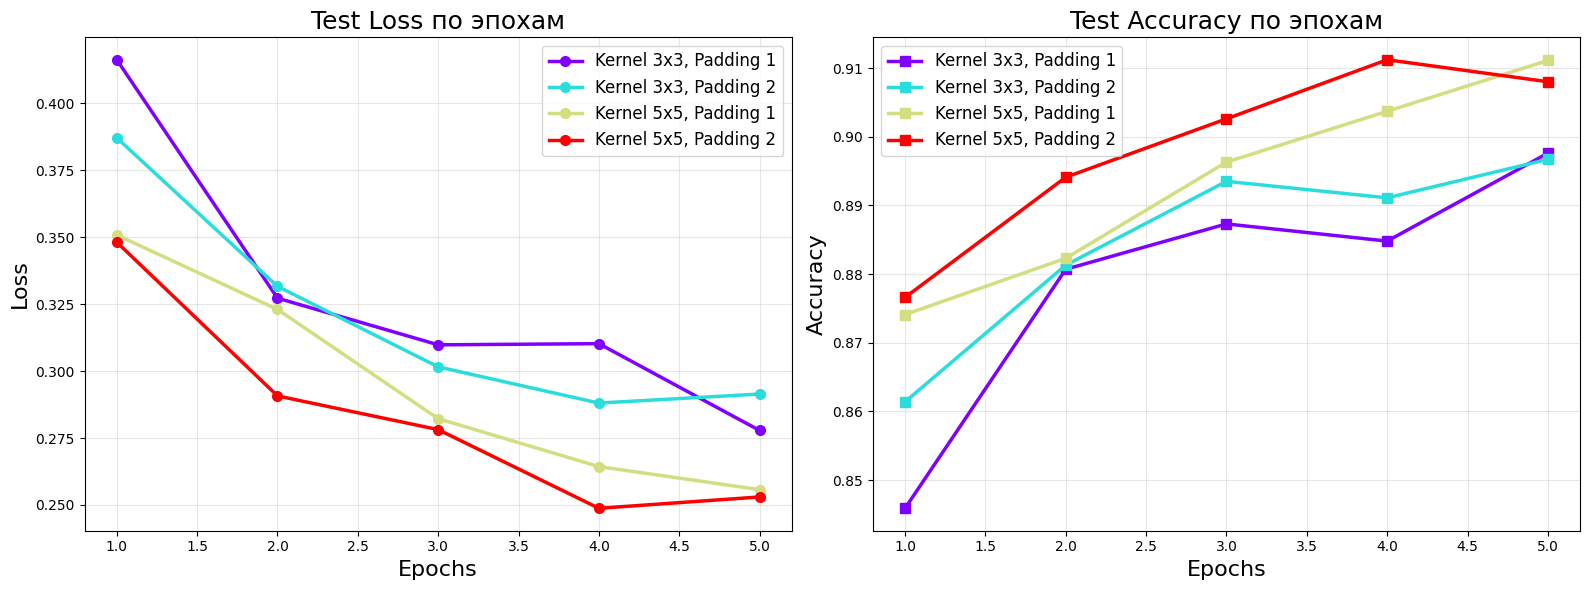

In [113]:
plot_comparison({name: data['history'] for name, data in fashion_results.items()})

model: Kernel 3x3, Padding 1:


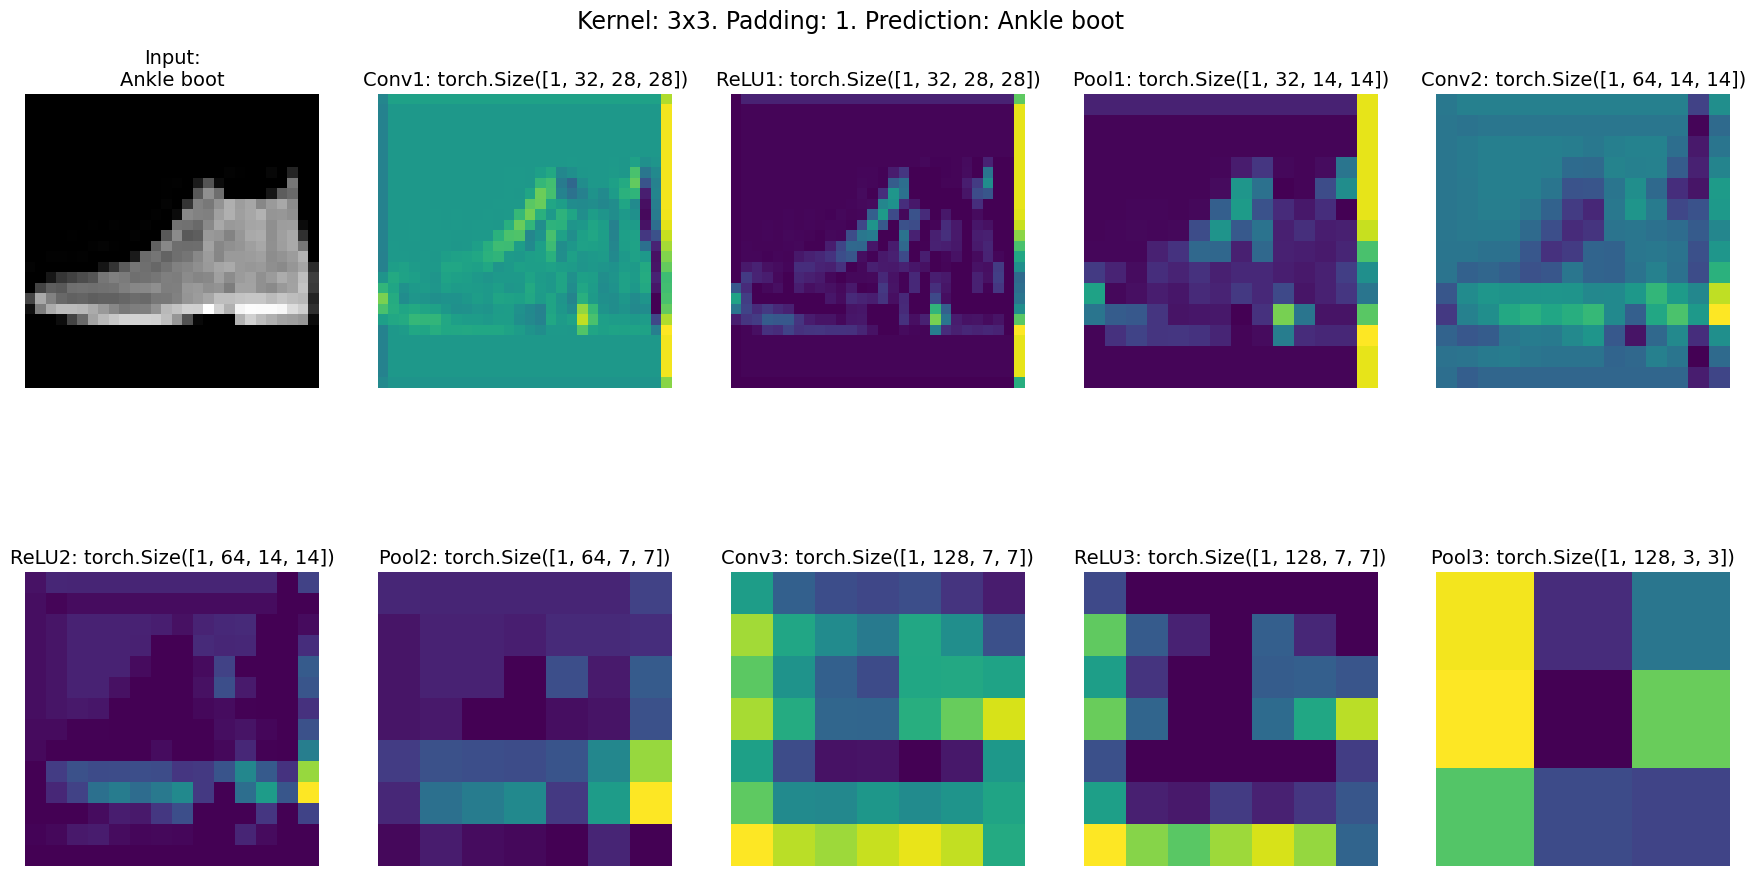

model: Kernel 3x3, Padding 2:


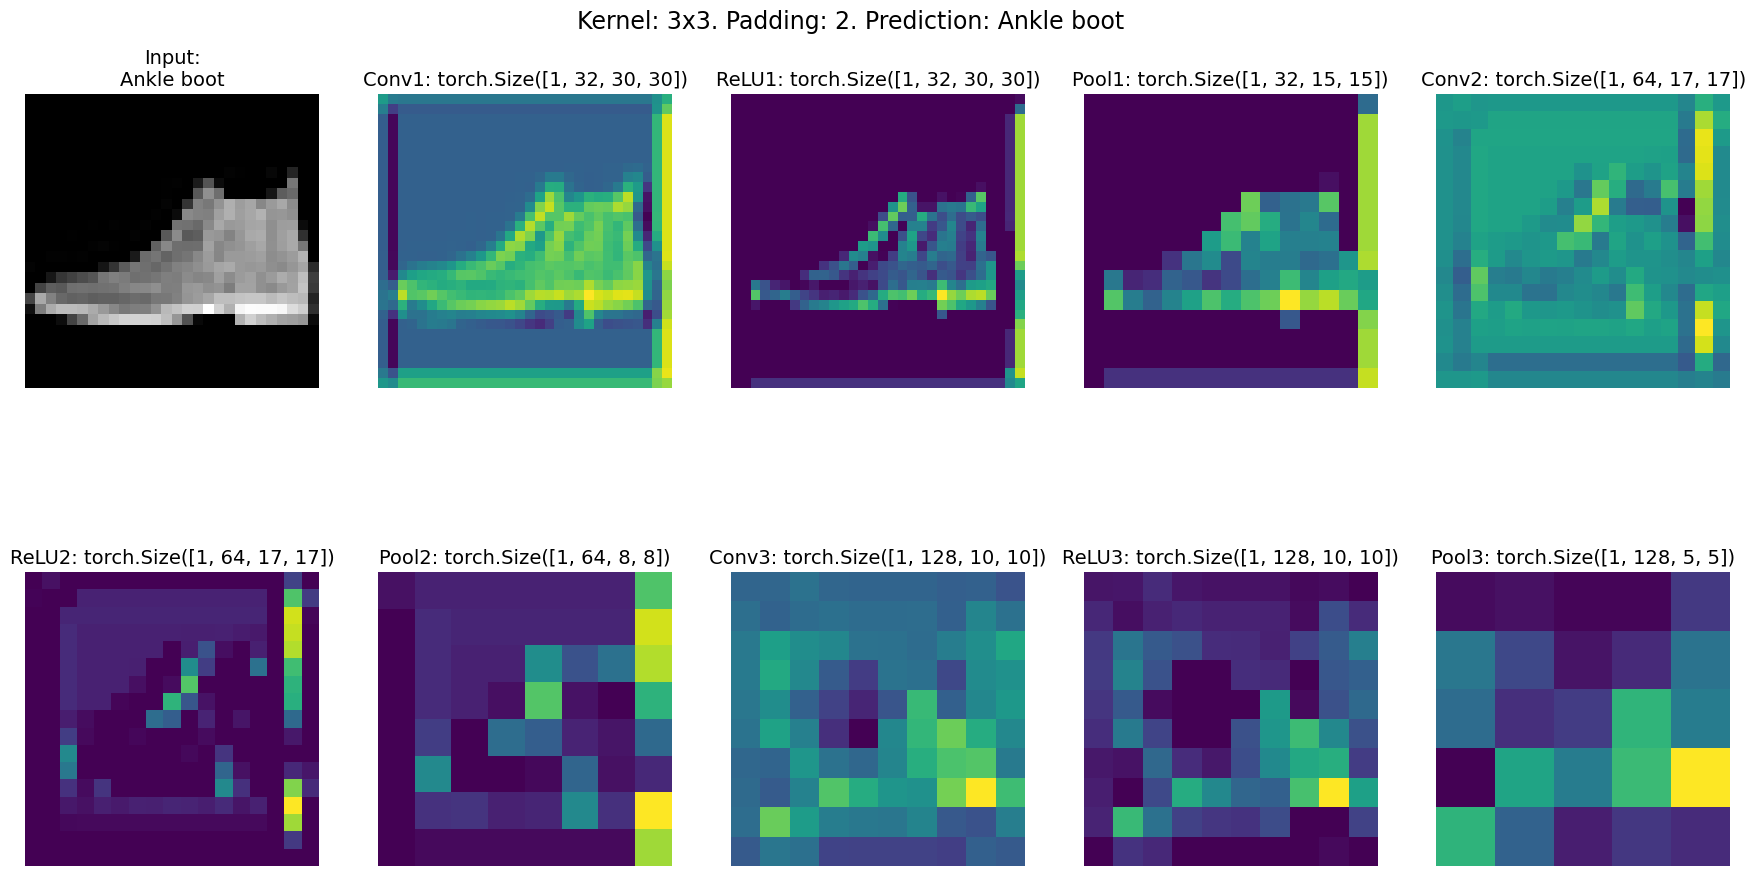

model: Kernel 5x5, Padding 1:


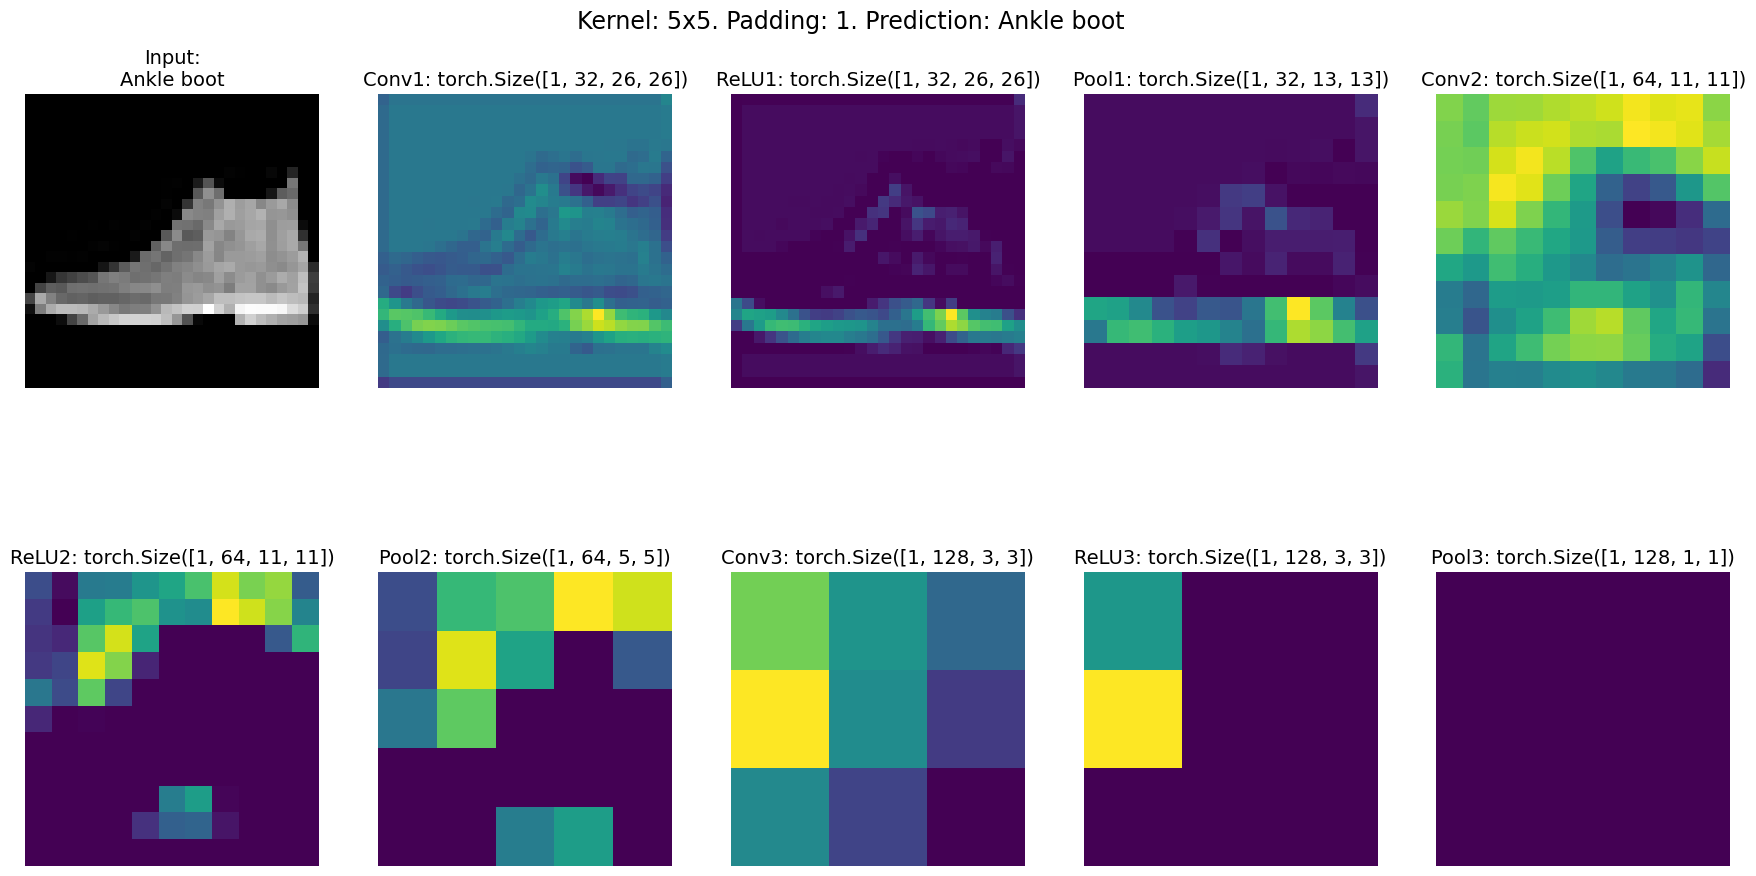

model: Kernel 5x5, Padding 2:


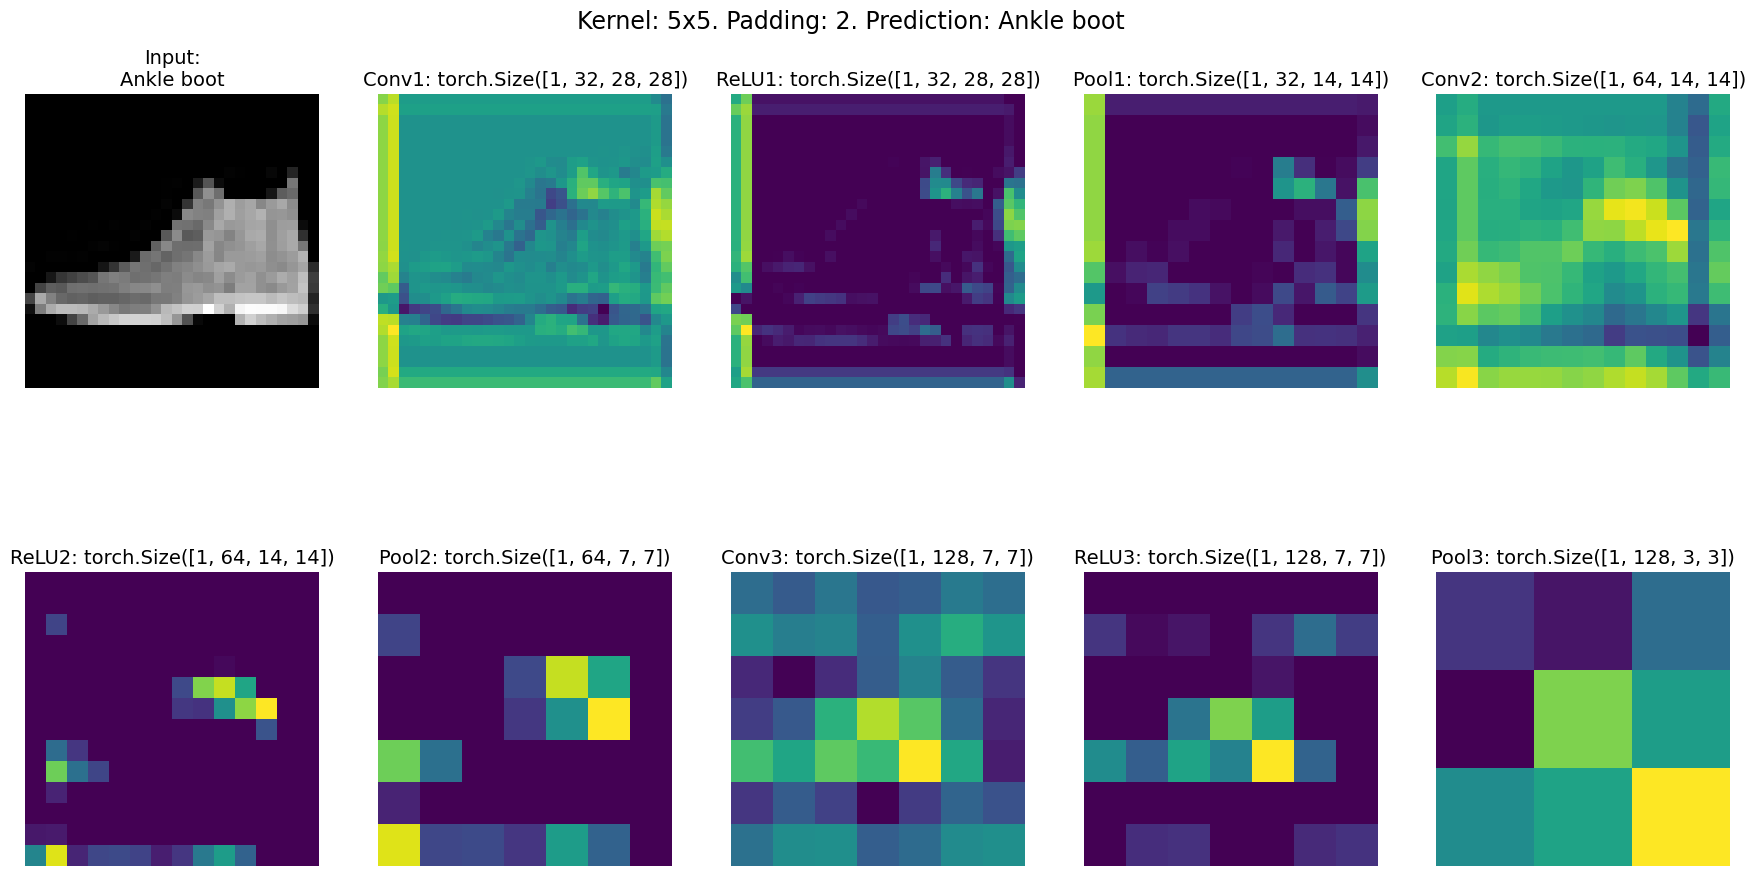

In [133]:
test_image, test_label = test_dataset_fashion[0]

for name, data in fashion_results.items():
    print(f"model: {name}:")
    visualize_layer_outputs(data['model'], test_image, test_label, device)

### Насчёт AvgPooling и MaxPooling

AvgPooling подойдёт больше в тех задачах, где изображения характеризуются не конкретными яркими пикселями, по которым можно определить это изображение, а каким-то общим паттерном, размытыми текстурами. Например:
- В обработке снимков рентгена, т.к. патологии часто проявляются как изменение средней плотности ткани, а не резкие края, т.е. важны плавные переходы и средняя интенсивность областей.
- Для классификации изображений с общей композицией, например пляж, который характеризуется соотношением песка, неба, воды. MaxPooling фокусируется на ярких объектах, поэтому может пропустить общий контекст. А вот AvgPooling учитывает весь контекст изображения.
- Распознавание эмоций, т.к. эмоция характеризуется общим выражением лица, а не отдельными резкими чертами. AvPooling сохраняет общую информацию о выражении лица.

- Сверточные сети
http://www.deeplearningbook.org/contents/convnets.html
http://www.deeplearningbook.org/contents/optimization.html

- Визуализация сверток
https://gist.github.com/akiross/754c7b87a2af8603da78b46cdaaa5598